In [1]:
#!pip uninstall scikit-learn -y

In [2]:
#!pip install scikit-learn==1.2.2

In [3]:
#!pip install xgboost

In [4]:
#!pip install lightgbm

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sn
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc 
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import uniform, randint
from sklearn.feature_selection import SelectFromModel


In [6]:
df = pd.read_csv('train_Final.csv')
df_test = pd.read_csv('test_Final.csv')

# Exploring & preprocessing

In [7]:
df.head(10)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0
5,5,0.0,1.052469,0.099592,1.077244,1.370024,-0.471625,0.238658,-0.281837,0.055925,...,-0.013418,0.210670,-0.031069,0.131544,0.452867,-0.376528,0.086428,0.049083,35.97,0
6,6,0.0,1.206129,0.420150,-0.358910,1.037382,0.735224,-0.082449,0.568558,-0.158037,...,-0.366513,-1.113867,0.042265,-0.819477,0.473615,-0.639652,0.006812,0.016747,36.00,0
7,7,0.0,-1.074970,-0.297535,-0.884465,0.065341,-0.239956,0.349602,1.756880,0.054202,...,0.624183,0.908389,-0.233799,-0.457045,0.551736,-0.064708,0.137524,0.203869,440.00,0
8,8,0.0,2.154065,-0.000479,-2.125939,-0.121096,0.918473,-0.208507,0.226055,-0.236828,...,0.243716,0.780992,-0.148060,-0.280708,0.507044,-0.420133,-0.037652,-0.079346,1.00,0
9,9,0.0,2.172667,-0.704020,-1.447412,-0.715805,-0.530117,-1.007526,-0.436662,-0.176599,...,0.502916,1.442638,-0.063396,0.017817,0.270144,0.240989,-0.057164,-0.081458,10.00,0


In [8]:
df.tail()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
149995,149995,73899.0,1.277125,0.665683,-0.688148,1.135626,0.494826,-0.554938,0.252478,-0.132739,...,-0.114747,-0.221548,-0.233038,-0.744995,0.799359,-0.244856,0.037868,0.042670,1.0,0
149996,149996,73899.0,0.807735,-1.813163,0.421073,-0.576839,-1.601656,-0.665517,-0.230382,-0.297095,...,0.270879,0.014436,-0.193669,0.387714,0.169280,-0.444501,-0.043788,0.072515,349.7,0
149997,149997,73899.0,0.836403,-0.351598,0.650338,1.066155,-0.234826,0.844271,-0.409578,0.382619,...,0.285914,0.721022,-0.067894,-0.273675,0.232969,-0.286735,0.054066,0.031396,116.1,0
149998,149998,73899.0,-0.806965,0.383847,2.296469,1.428714,-2.343948,1.073324,-0.203567,0.456589,...,0.228740,1.296798,-0.038753,0.827484,-0.743000,0.914488,0.307576,-0.010200,179.0,0
149999,149999,73899.0,1.146412,-1.058955,0.726353,0.425955,-1.150291,0.009909,-0.856315,0.025132,...,-0.308839,-0.634263,-0.121748,-0.566361,0.353399,-0.302464,0.064652,0.037291,118.0,0


In [9]:
df.shape

(150000, 32)

In [10]:
df.columns

Index(['id', 'Time', 'feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6',
       'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'feat13',
       'feat14', 'feat15', 'feat16', 'feat17', 'feat18', 'feat19', 'feat20',
       'feat21', 'feat22', 'feat23', 'feat24', 'feat25', 'feat26', 'feat27',
       'feat28', 'Transaction_Amount', 'IsFraud'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 32 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  150000 non-null  int64  
 1   Time                150000 non-null  float64
 2   feat1               150000 non-null  float64
 3   feat2               150000 non-null  float64
 4   feat3               150000 non-null  float64
 5   feat4               150000 non-null  float64
 6   feat5               150000 non-null  float64
 7   feat6               150000 non-null  float64
 8   feat7               150000 non-null  float64
 9   feat8               150000 non-null  float64
 10  feat9               150000 non-null  float64
 11  feat10              150000 non-null  float64
 12  feat11              150000 non-null  float64
 13  feat12              150000 non-null  float64
 14  feat13              150000 non-null  float64
 15  feat14              150000 non-nul

In [12]:
df.describe()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,...,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,74999.500000,49785.422340,0.069456,-0.003674,0.739860,0.104810,-0.254623,0.151934,-0.165443,0.166254,...,-0.032077,-0.068876,-0.059646,-0.000776,0.161152,0.021575,0.014138,0.020323,71.065194,0.001793
std,43301.414527,18733.655609,1.346553,1.161502,1.012801,1.230909,1.048268,1.182964,0.802668,0.691267,...,0.404916,0.573755,0.323272,0.584270,0.385175,0.473795,0.223692,0.163429,158.712510,0.042310
min,0.000000,0.000000,-22.173926,-44.247914,-19.088980,-5.069484,-21.090735,-25.659750,-31.179799,-28.903442,...,-14.689621,-7.351378,-11.958588,-2.827444,-3.958591,-1.413857,-9.234767,-4.454059,0.000000,0.000000
25%,37499.750000,39411.000000,-0.844248,-0.621724,0.181373,-0.738399,-0.912254,-0.590892,-0.667139,-0.078114,...,-0.185077,-0.464426,-0.177546,-0.321495,-0.078682,-0.310948,-0.044800,0.001623,6.990000,0.000000
50%,74999.500000,53785.000000,0.671327,0.003677,0.826497,0.095342,-0.322525,-0.068690,-0.144551,0.125052,...,-0.044828,-0.045844,-0.068170,0.043048,0.181701,-0.087927,0.017590,0.024098,24.900000,0.000000
75%,112499.250000,63833.000000,1.171271,0.753340,1.360362,0.967657,0.242796,0.492931,0.334553,0.396056,...,0.100896,0.309938,0.047399,0.388969,0.425791,0.269844,0.073776,0.065778,74.000000,0.000000
max,149999.000000,73899.000000,2.390816,16.068473,6.145578,12.547997,34.581260,15.082516,23.256066,18.270586,...,22.062945,6.163541,12.734391,4.572739,3.111624,3.119824,6.457839,23.263746,6513.350000,1.000000


### Outliers

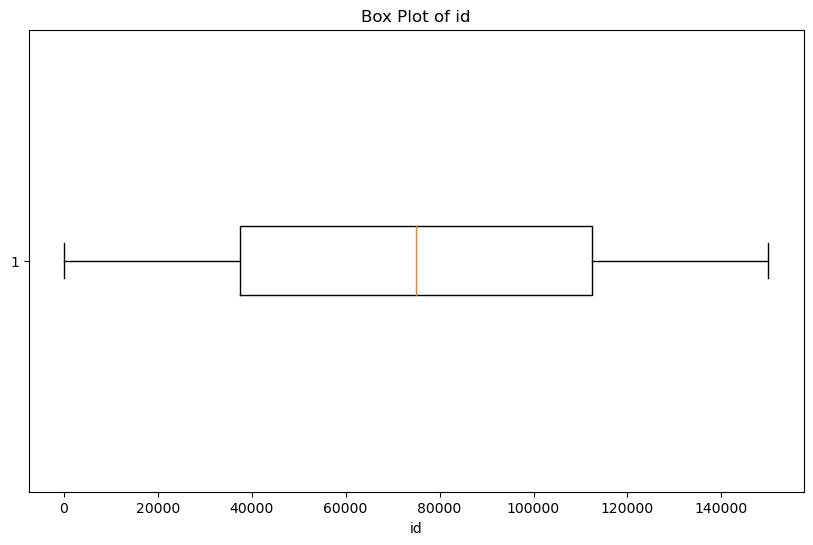

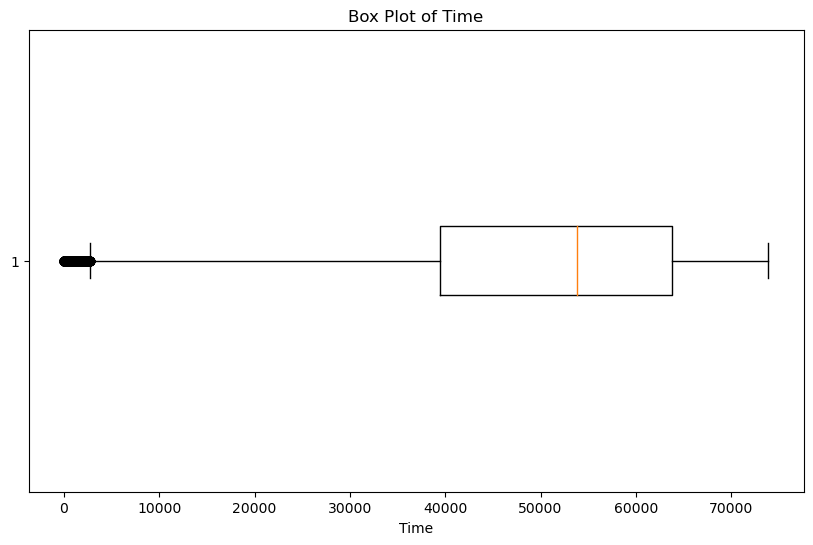

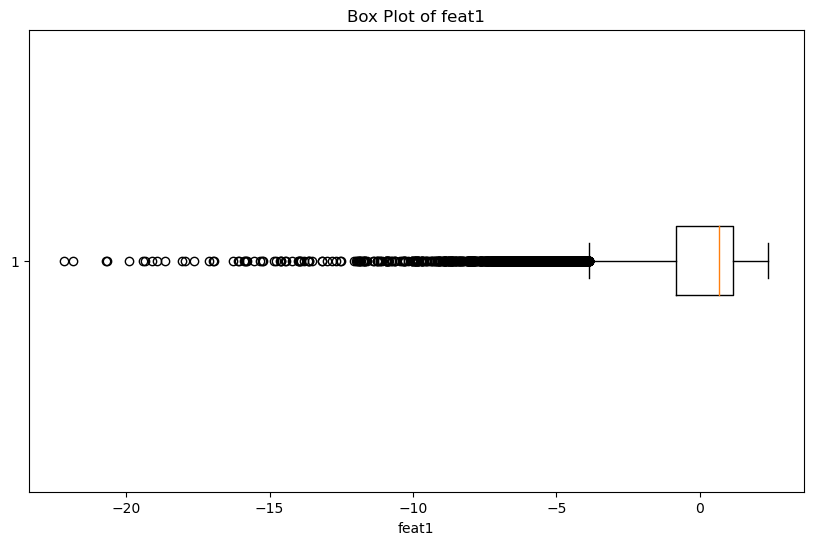

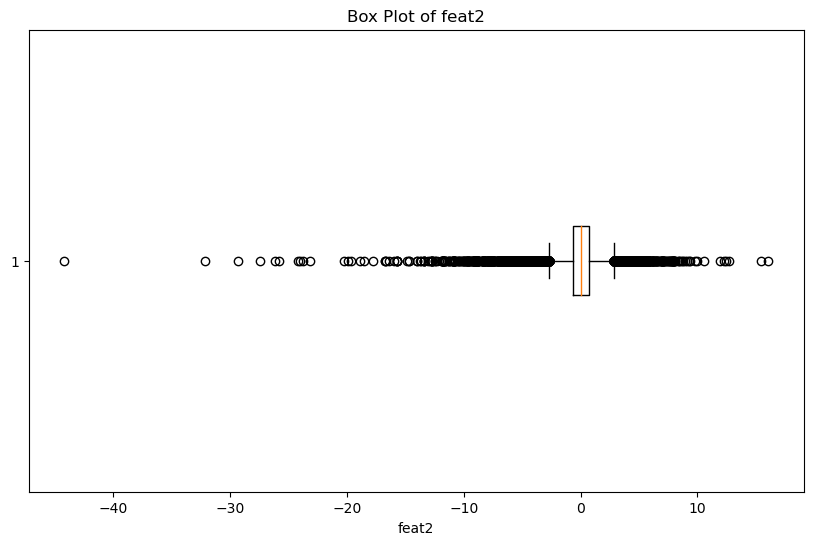

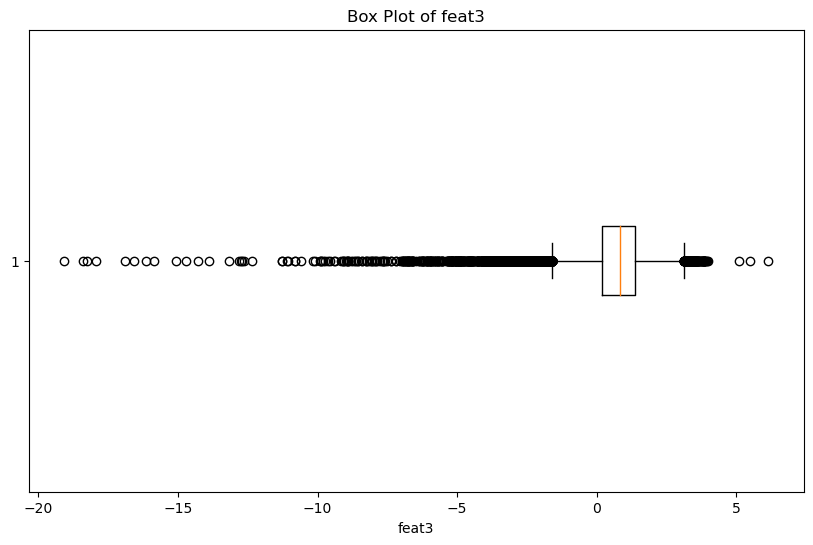

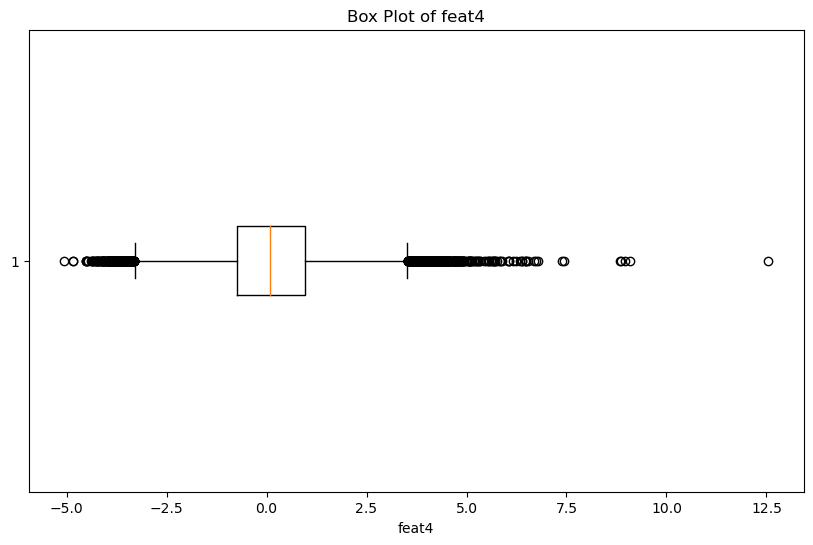

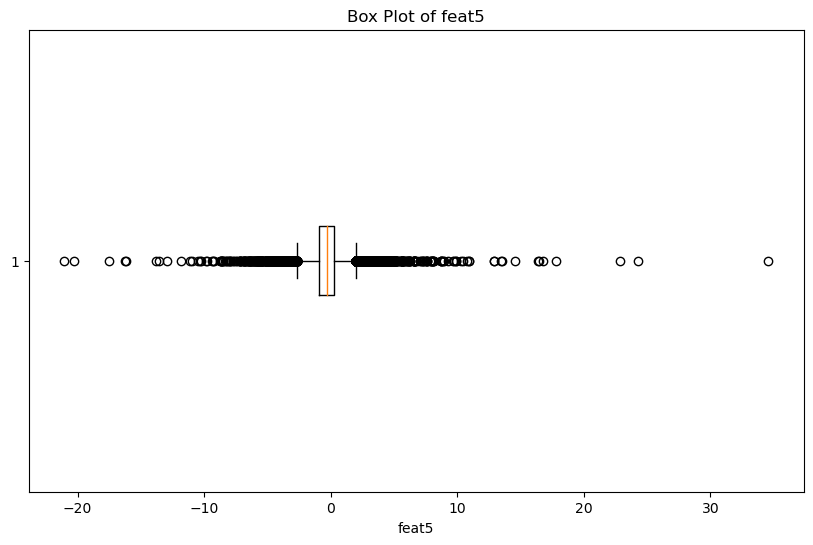

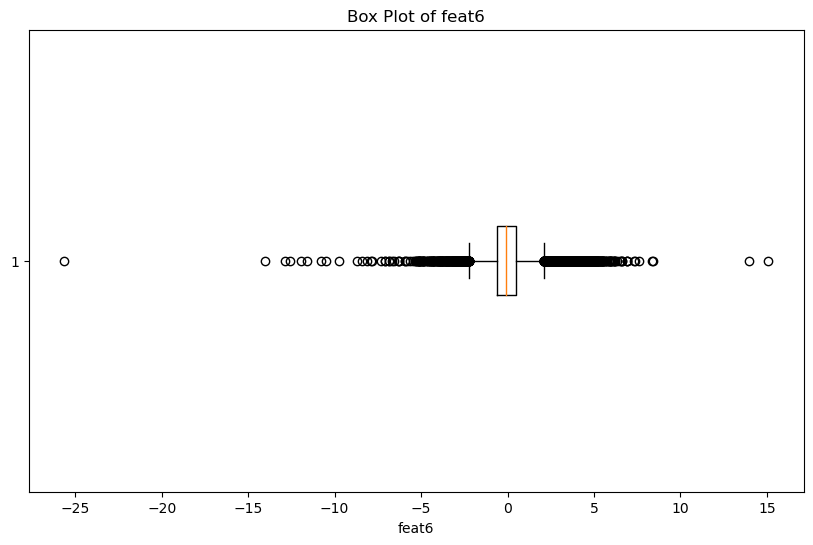

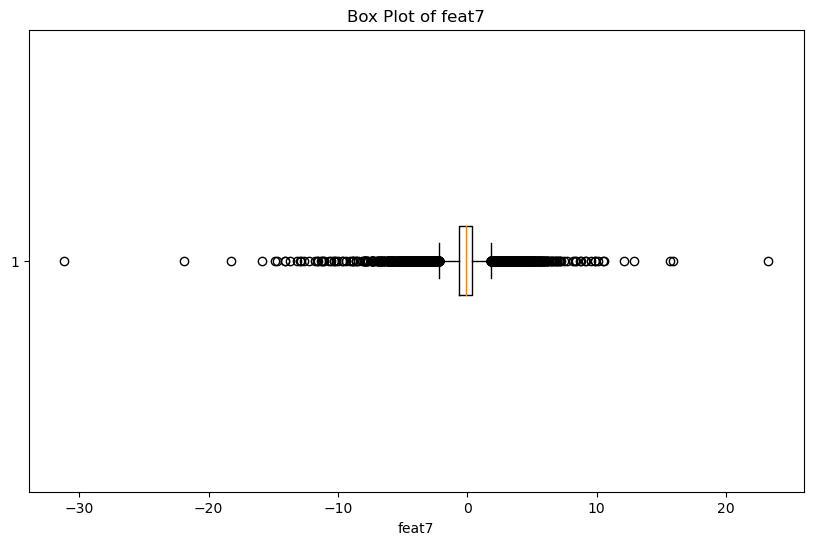

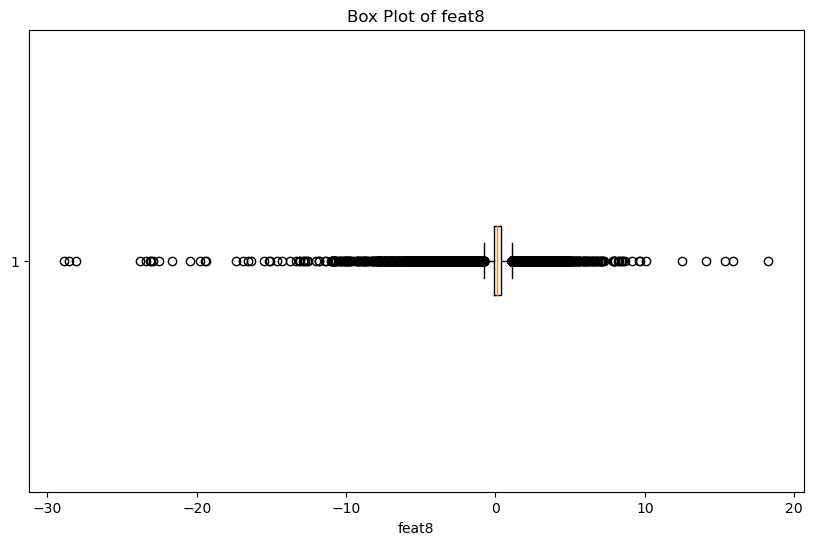

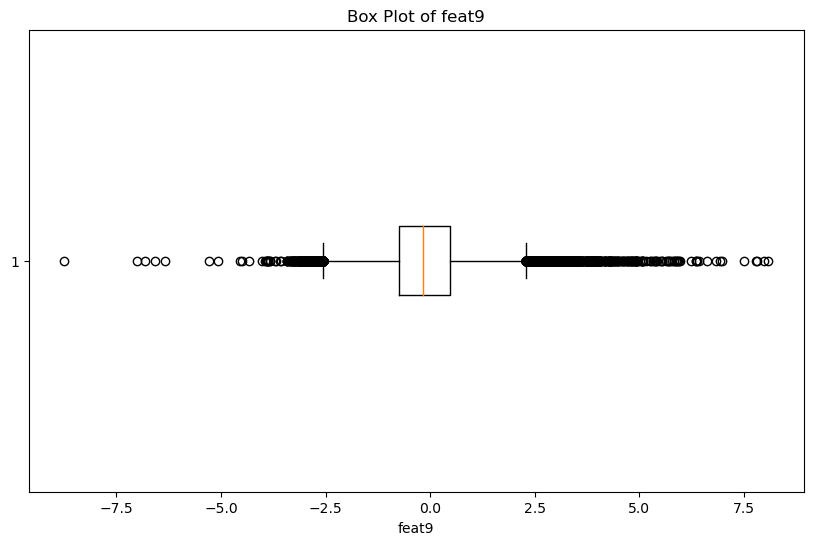

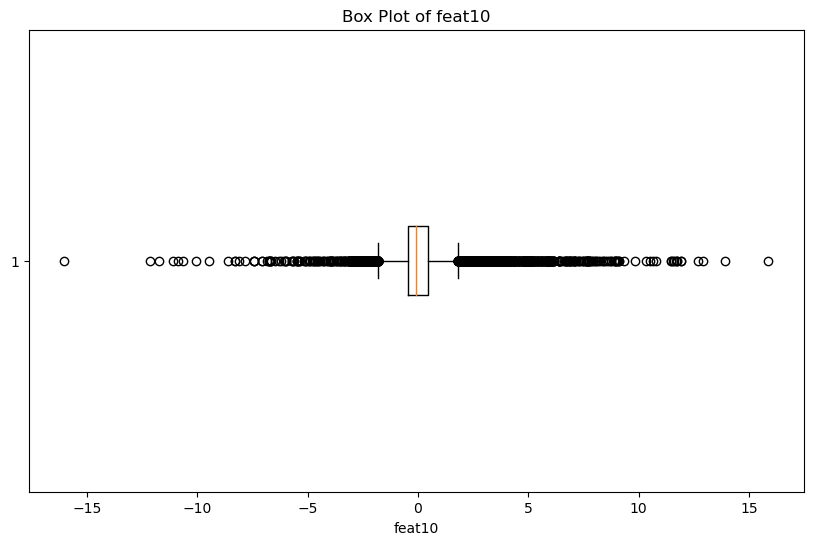

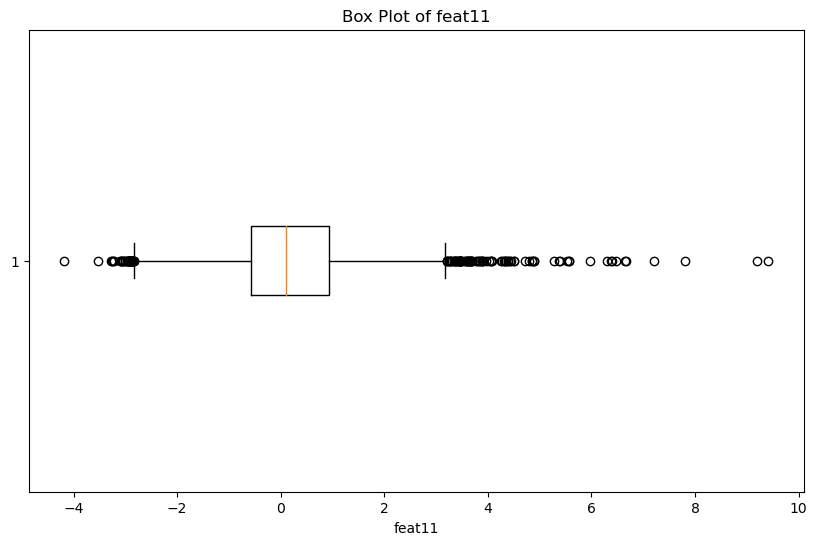

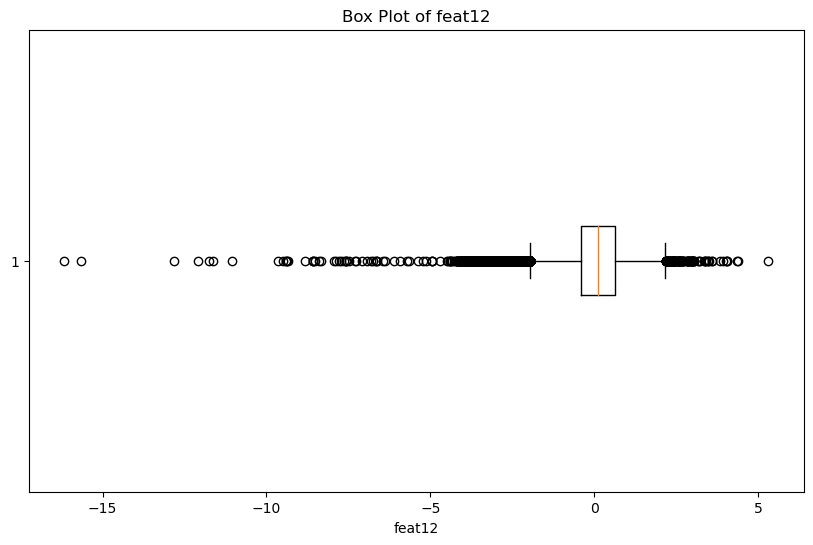

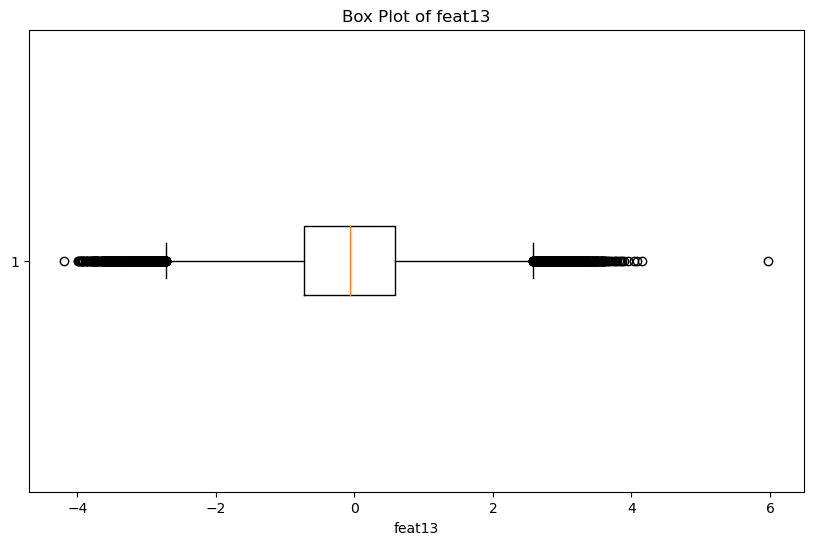

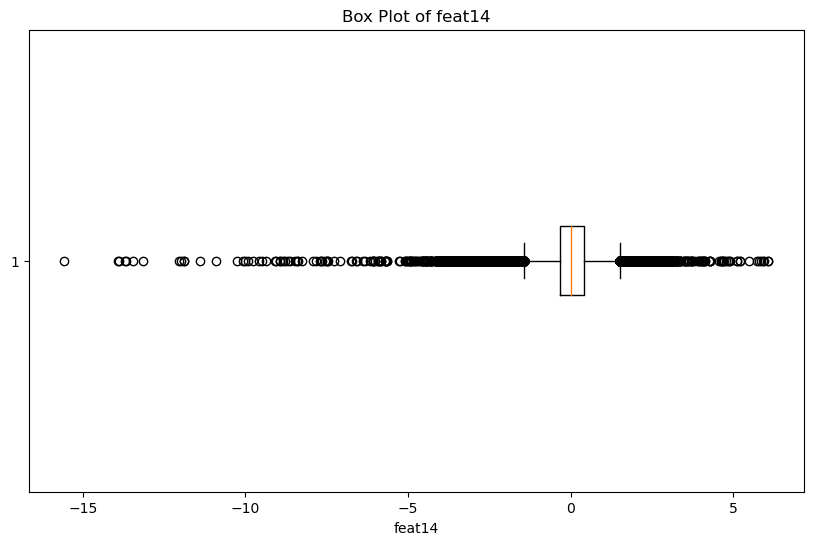

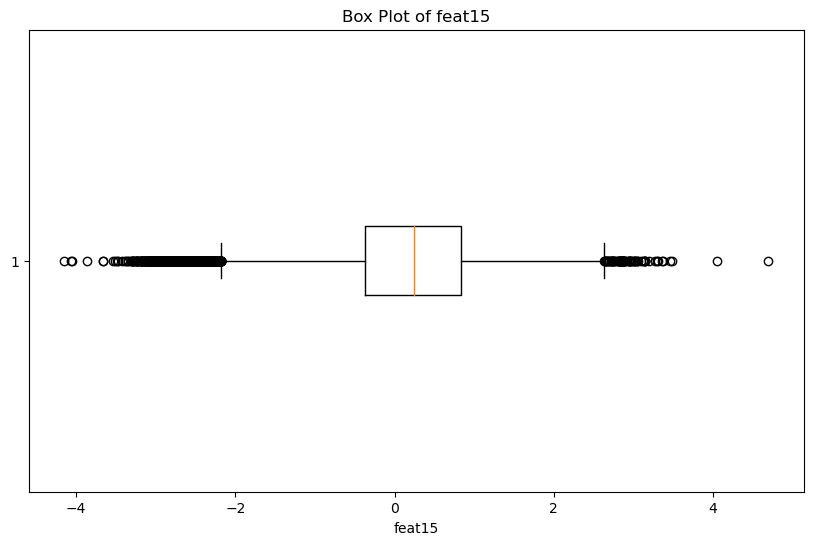

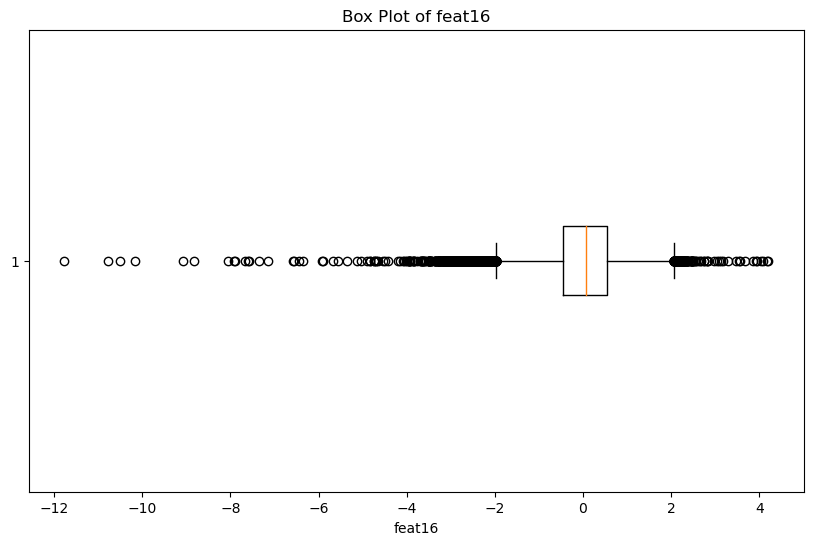

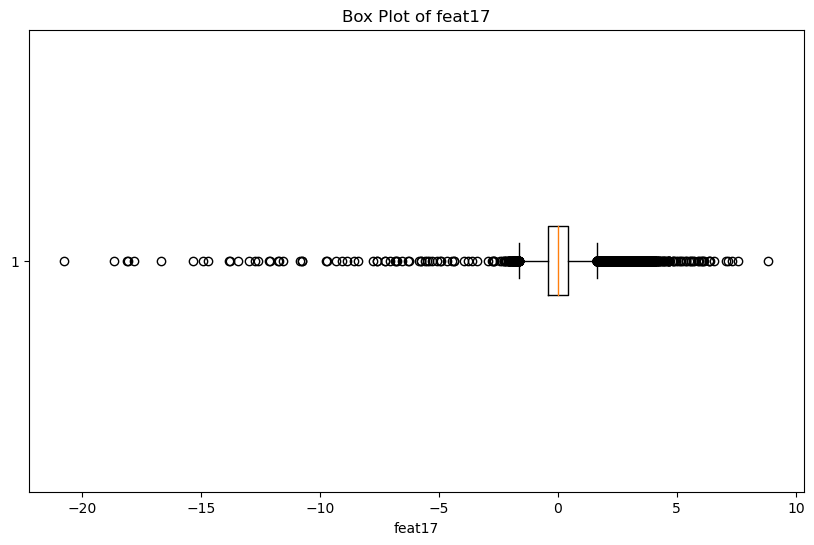

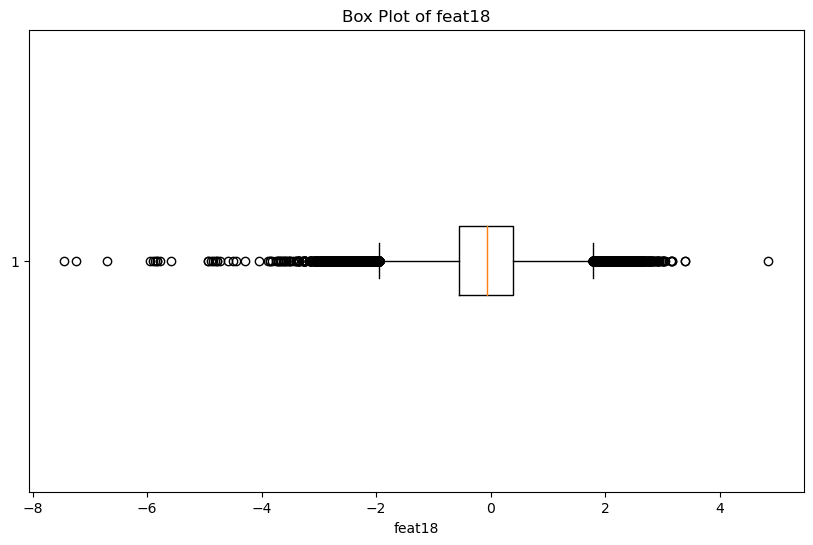

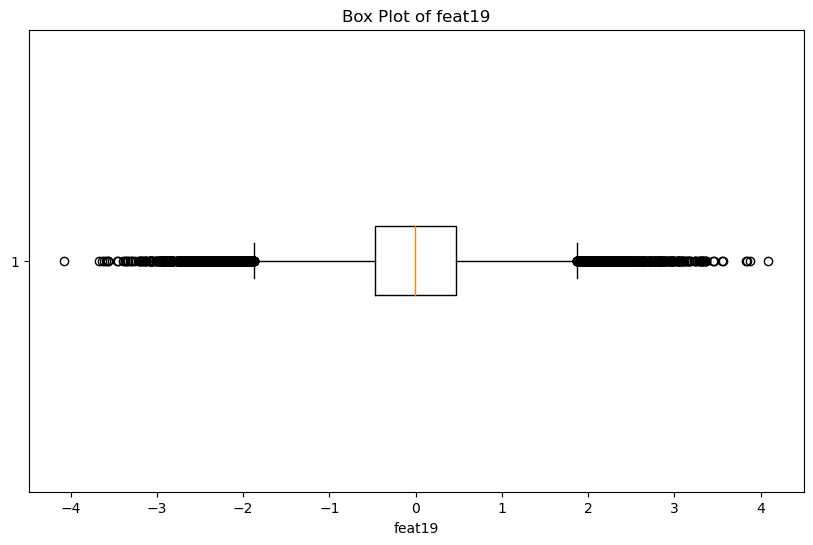

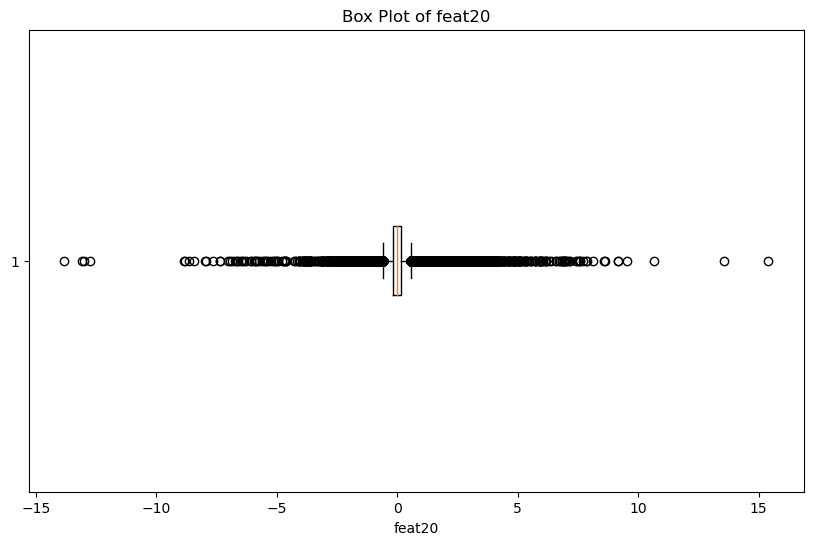

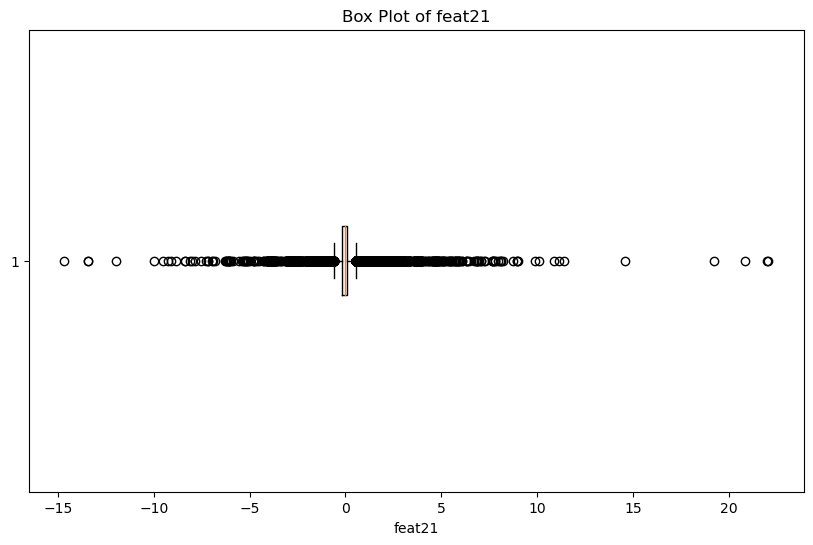

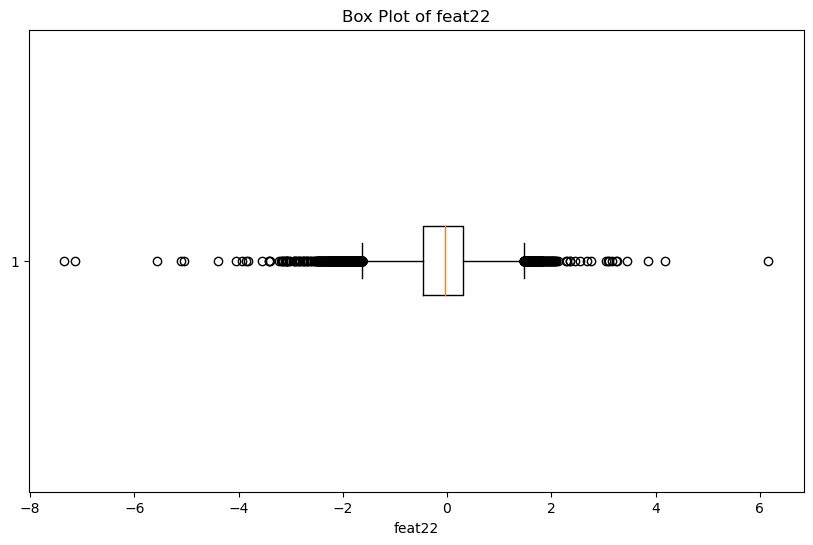

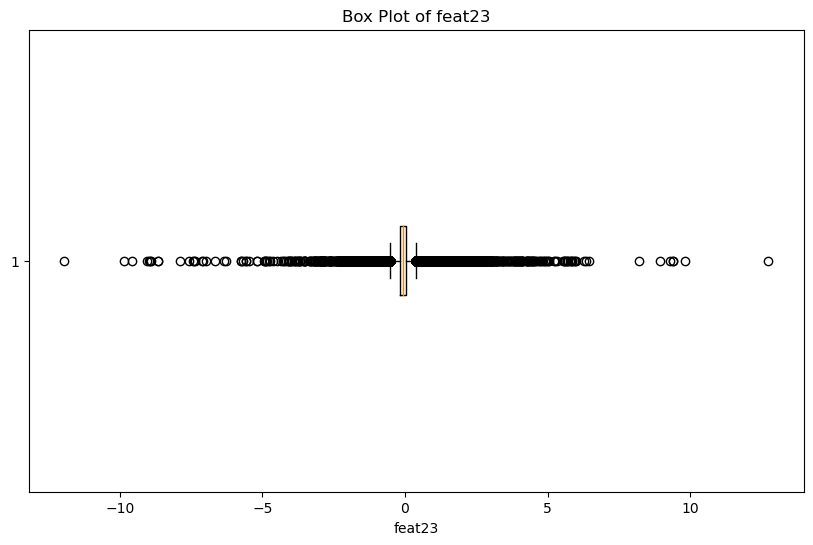

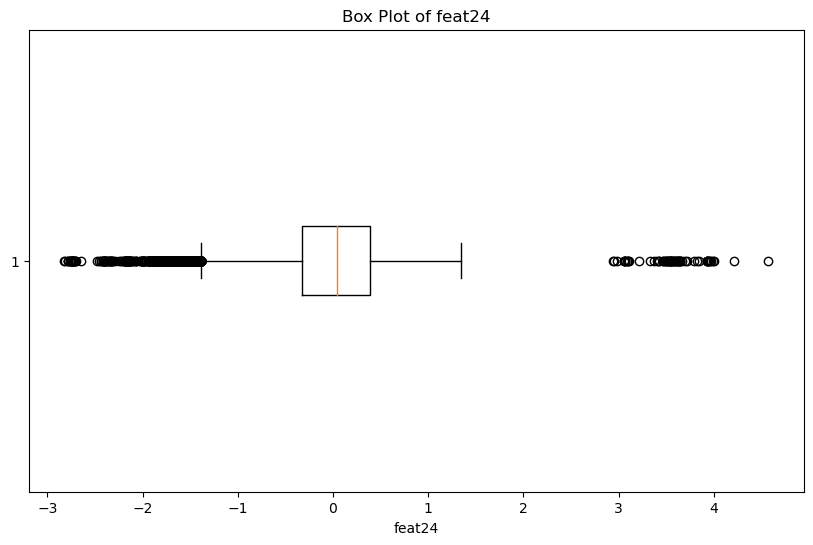

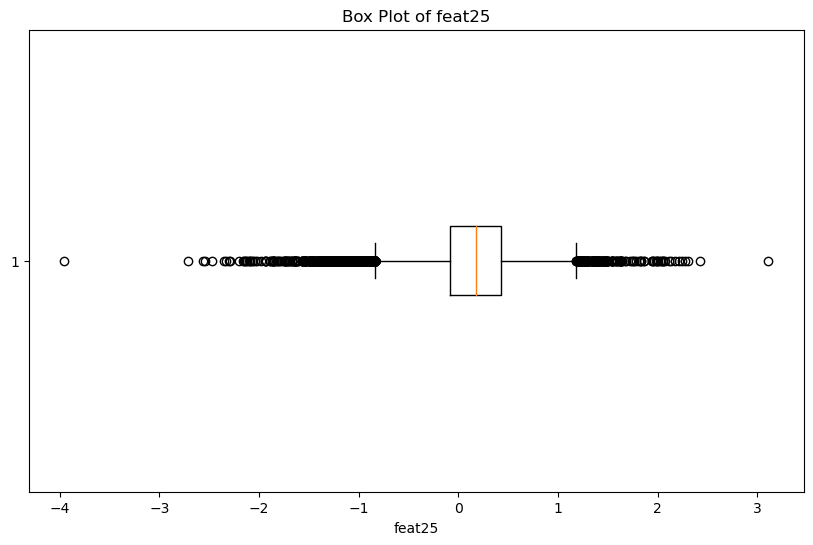

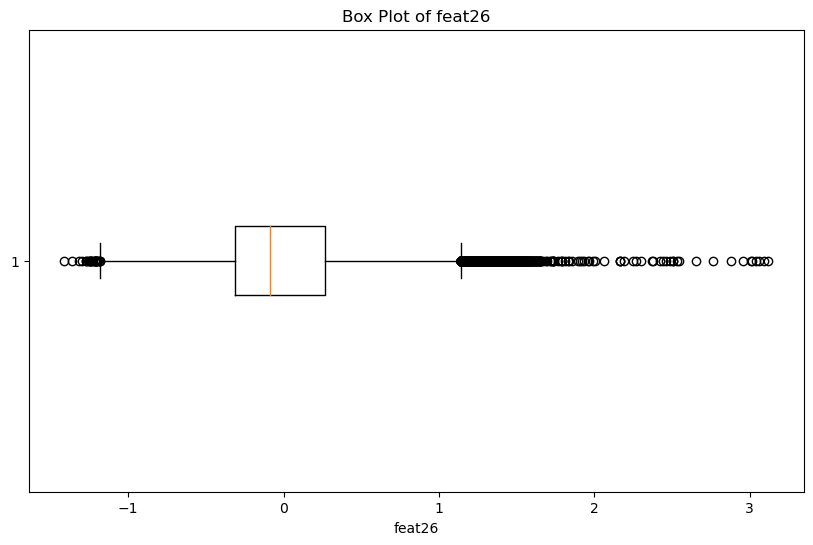

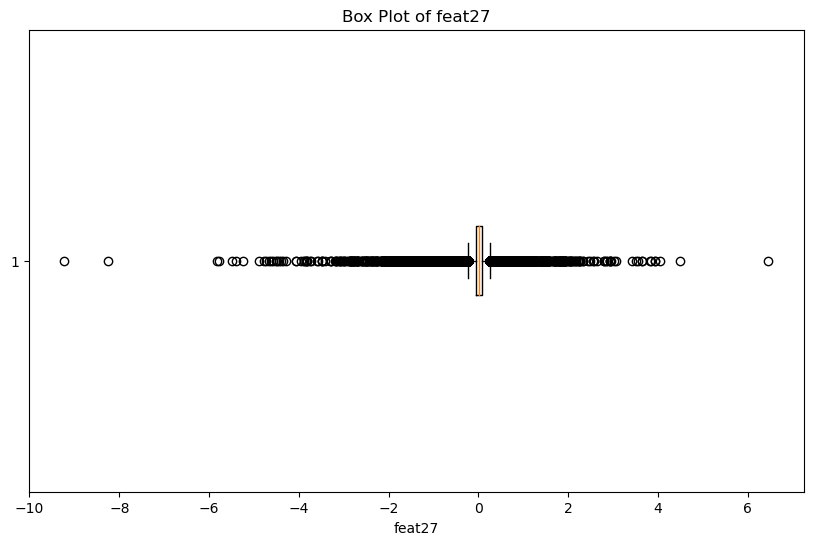

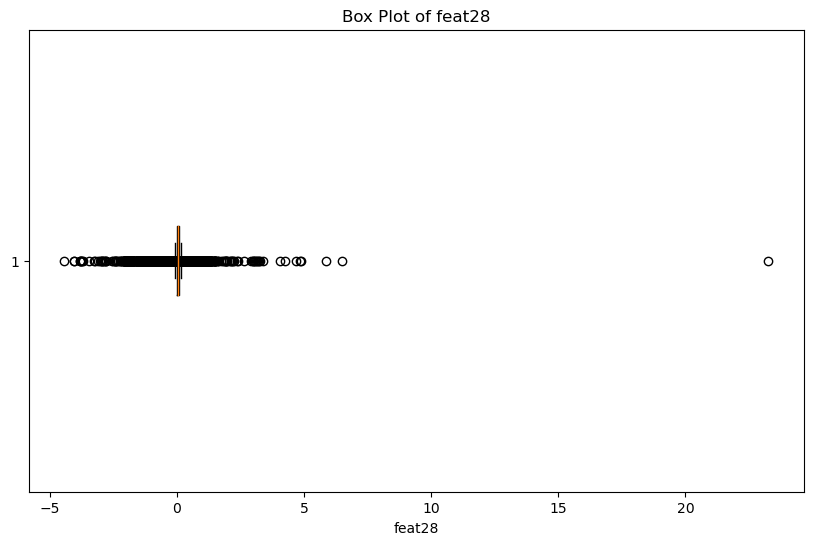

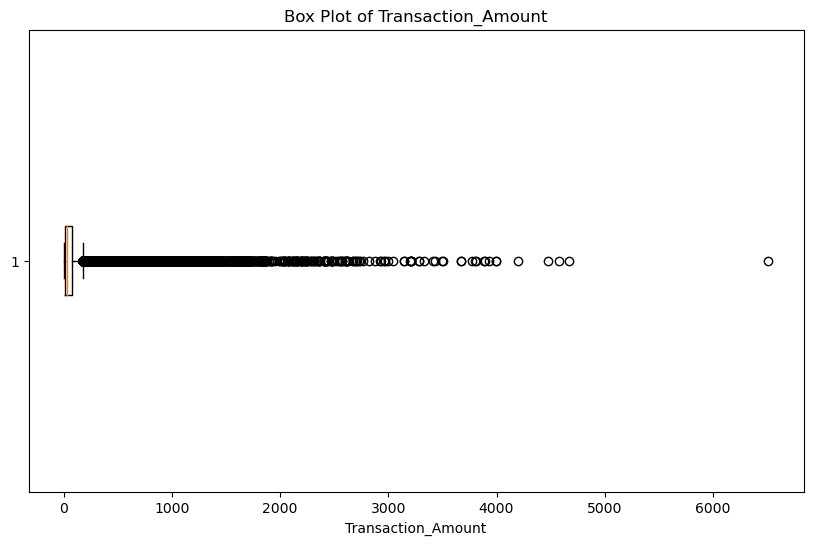

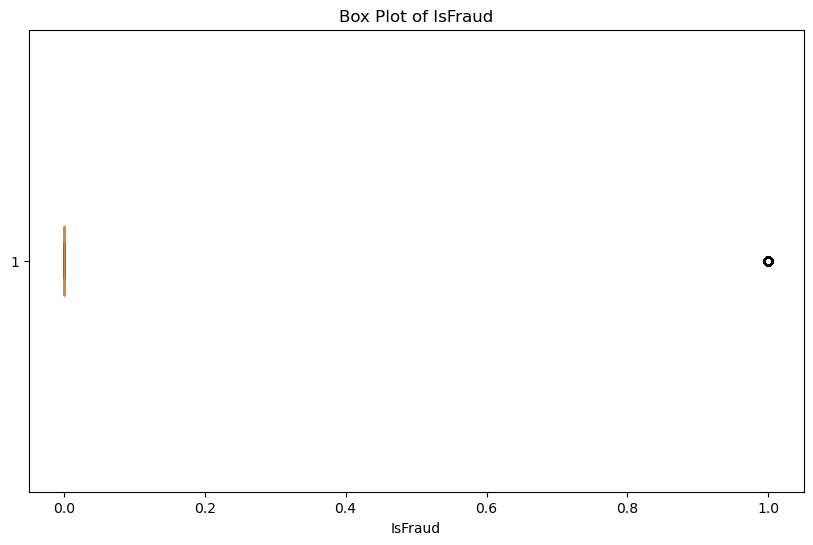

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
numeric_features = df.select_dtypes(include=['number']).columns
# Select the last 5 numeric features
last_5_features = numeric_features[:]
# Plot box plots  
for feature in last_5_features:
    plt.figure(figsize=(10, 6))
    plt.boxplot(df[feature].dropna(), vert=False)
    plt.title(f'Box Plot of {feature}')
    plt.xlabel(feature)
    plt.show()

### Missing values and duplication

In [14]:
# missing 
print(df.isnull().sum())

id                    0
Time                  0
feat1                 0
feat2                 0
feat3                 0
feat4                 0
feat5                 0
feat6                 0
feat7                 0
feat8                 0
feat9                 0
feat10                0
feat11                0
feat12                0
feat13                0
feat14                0
feat15                0
feat16                0
feat17                0
feat18                0
feat19                0
feat20                0
feat21                0
feat22                0
feat23                0
feat24                0
feat25                0
feat26                0
feat27                0
feat28                0
Transaction_Amount    0
IsFraud               0
dtype: int64


In [15]:
#duplicate
df.duplicated().sum()

0

### Drop not needed column

In [16]:
#df.drop(["id"], axis = 1, inplace = True)

### Feature selection and Correlation

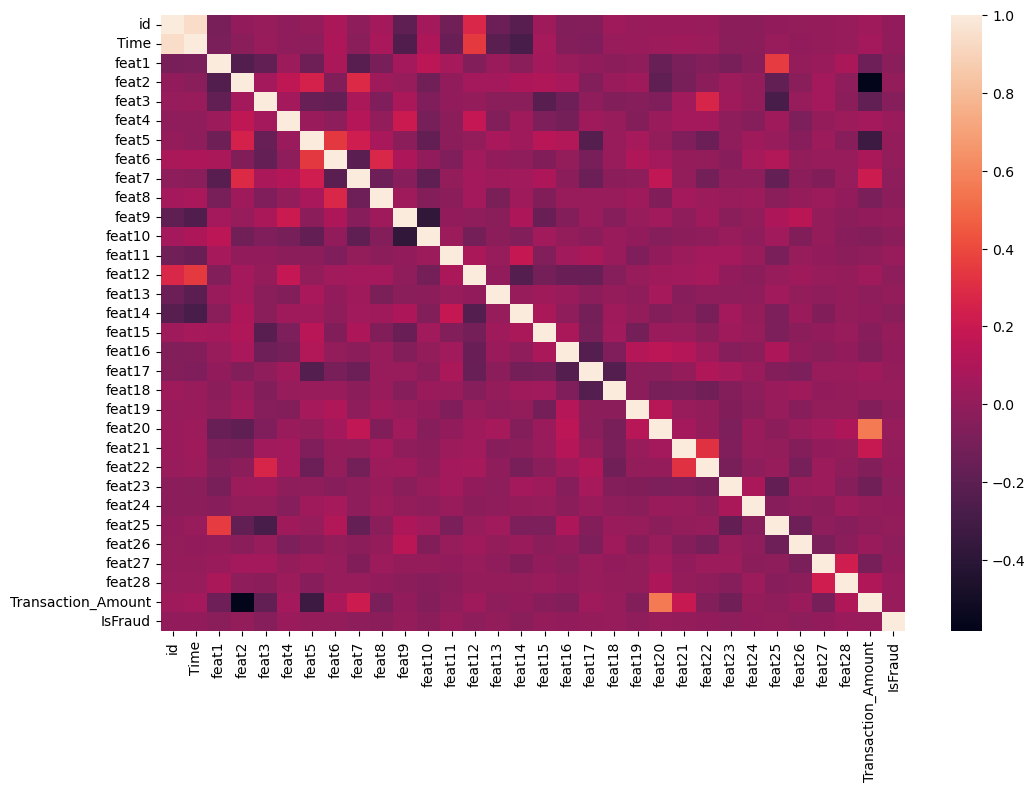

In [17]:
#discover how various numerical features in the dataset  
corr_matrix = df.select_dtypes(include=['int64','float64']).corr()
f, ax = plt.subplots(figsize=(12, 8))
sn.heatmap(corr_matrix, annot=False)
plt.show()

### Feature Scaling:

In [18]:
# Separate features and target in train data
X_train = df.drop('IsFraud', axis=1)
y_train = df['IsFraud']

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(df_test)

### Imbalance classes 

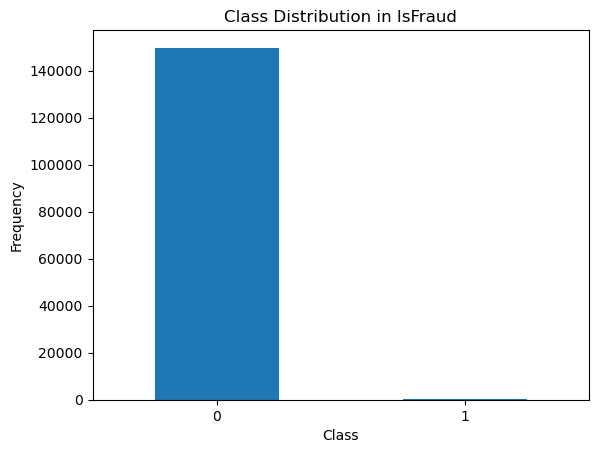

IsFraud
0    149731
1       269
Name: count, dtype: int64


In [19]:
# Check the distribution of the classes 0, 1 in  'IsFraud' column 
IsFraud_distribution = df['IsFraud'].value_counts()

# bar chart
IsFraud_distribution.plot(kind='bar')
plt.title('Class Distribution in IsFraud')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

print(IsFraud_distribution)


# Train and Evaluate Models Before Handling Imbalance
 

In [20]:
# Train-validation split
X_train_initial, X_val_initial, y_train_initial, y_val_initial = train_test_split(X_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [21]:
# Define the evaluate function
def evaluate_model(model, X_val, y_val):
    y_val_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    #roc_auc = roc_auc_score(y_val, y_val_pred)
    
    # Display confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    
    return accuracy, precision, recall, f1 

C:\Users\Msys\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


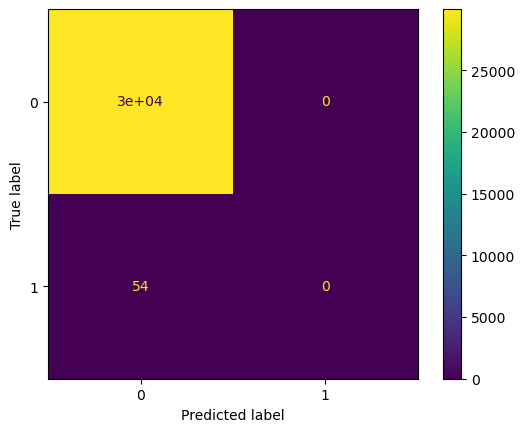

Before Handling Imbalance - Accuracy: 0.9982, Precision: 0.0, Recall: 0.0, F1 Score: 0.0 


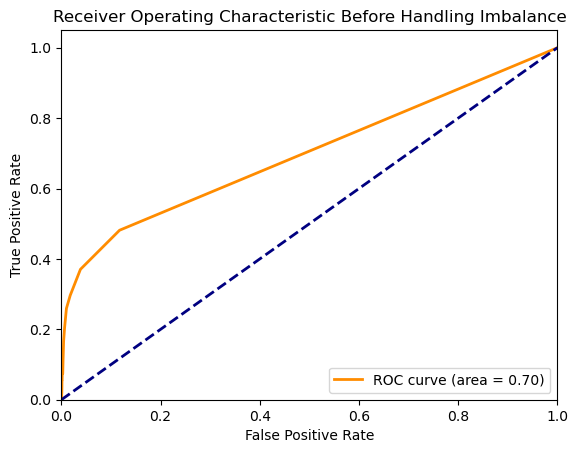

In [22]:
# Train a model before handling imbalance
model_before = RandomForestClassifier(random_state=42)
model_before.fit(X_train_initial, y_train_initial)

 
metrics_before = evaluate_model(model_before, X_val_initial, y_val_initial)
print(f'Before Handling Imbalance - Accuracy: {metrics_before[0]}, Precision: {metrics_before[1]}, Recall: {metrics_before[2]}, F1 Score: {metrics_before[3]} ')

# Draw the ROC curve
y_val_pred_prob_before = model_before.predict_proba(X_val_initial)[:, 1]
fpr, tpr, _ = roc_curve(y_val_initial, y_val_pred_prob_before)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Before Handling Imbalance')
plt.legend(loc='lower right')
plt.show()


# Handle Imbalanced Data using Synthetic Minority Over-sampling Technique (SMOTE)

In [23]:
# Handle imbalanced data with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Train-validation split for resampled data
X_train_resampled, X_val_resampled, y_train_resampled, y_val_resampled = train_test_split(X_train_res, y_train_res, test_size=0.2, stratify=y_train_res, random_state=42)


# class distribution after SMOTE
print("Class distribution after SMOTE:")
print(y_train_resampled.value_counts())


Class distribution after SMOTE:
IsFraud
1    119785
0    119784
Name: count, dtype: int64


# Train a model after handling imbalance

###  RandomForest

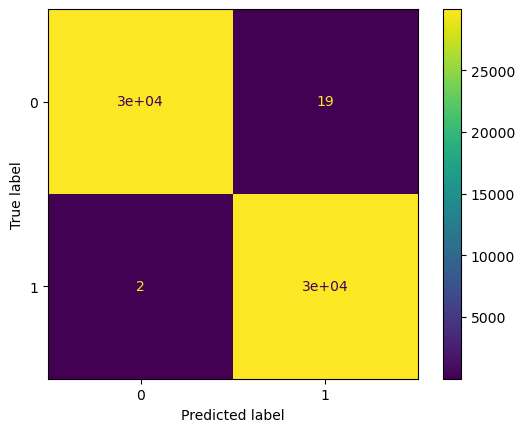

After Handling Imbalance - Accuracy: 0.9996493747182476, Precision: 0.9993658845909955, Recall: 0.9999332131169438, F1 Score: 0.9996494683603466


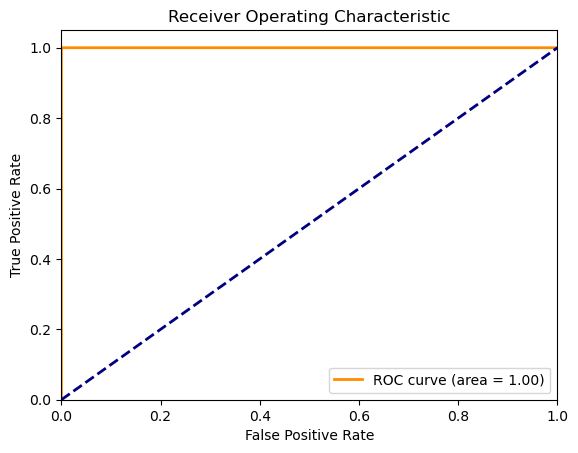

In [24]:
# Train the model
model_after = RandomForestClassifier(random_state=42)
model_after.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set
metrics_after = evaluate_model(model_after, X_val_resampled, y_val_resampled)
print(f'After Handling Imbalance - Accuracy: {metrics_after[0]}, Precision: {metrics_after[1]}, Recall: {metrics_after[2]}, F1 Score: {metrics_after[3]}')

 
# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = model_after.predict_proba(X_val_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


# Train the final model on the entire resampled training data
model_after.fit(X_train_res, y_train_res)

# test data
y_test_pred_proba = model_after.predict_proba(X_test_scaled)[:, 1]

# submission file
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_random.csv', index=False)


* score for test : private: 0.50582, public: 0.55606

### Logistic Regression

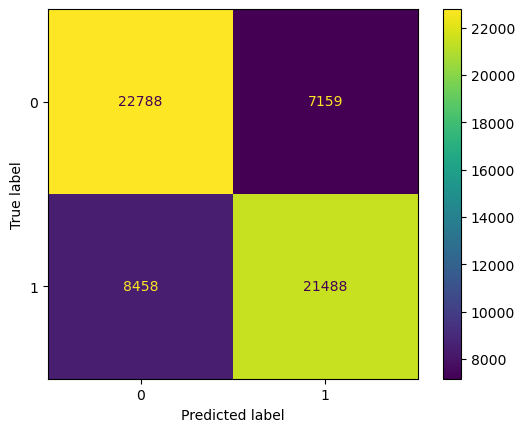

Logistic Regression - Accuracy: 0.7392516654700884, Precision: 0.750095996090341, Recall: 0.7175582715554665, F1 Score: 0.7334664550372911


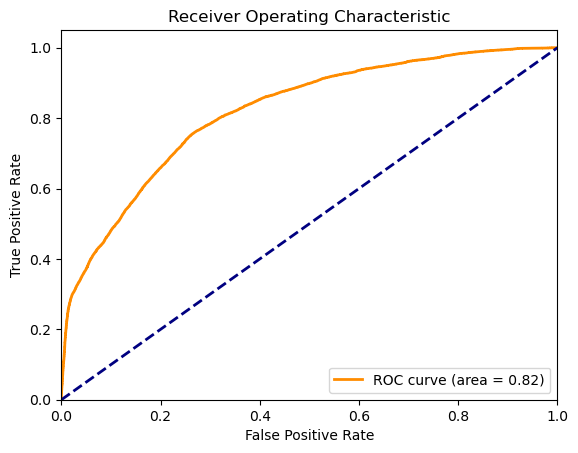

In [25]:
# Train the model  
model_logistic = LogisticRegression(random_state=42)
model_logistic.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set
metrics_logistic = evaluate_model(model_logistic, X_val_resampled, y_val_resampled)
print(f'Logistic Regression - Accuracy: {metrics_logistic[0]}, Precision: {metrics_logistic[1]}, Recall: {metrics_logistic[2]}, F1 Score: {metrics_logistic[3]}')

# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = model_logistic.predict_proba(X_val_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final model on the entire resampled training data
model_logistic.fit(X_train_res, y_train_res)

# test data 
y_test_pred_proba = model_logistic.predict_proba(X_test_scaled)[:, 1]

# submission file 
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_logistic.csv', index=False)


* score for test : private: 0.50582, public: 0.55606

### NaiveBayes

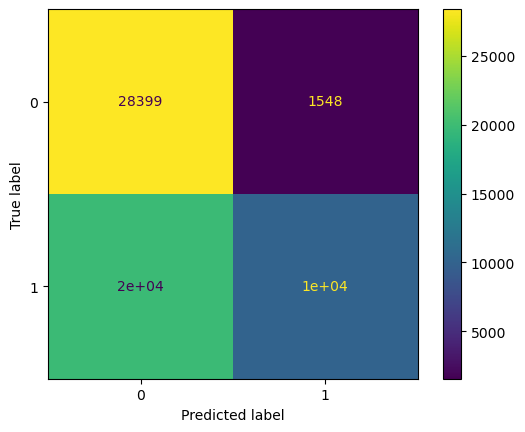

Naive Bayes - Accuracy: 0.6428631058721387, Precision: 0.8671472708547889, Recall: 0.3374073331997596, F1 Score: 0.485792586182028  


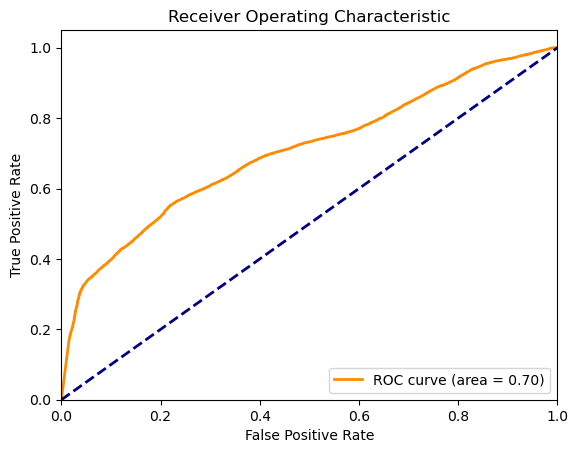

In [26]:
# Train the model  
model_nb = GaussianNB()
model_nb.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set  
metrics_nb = evaluate_model(model_nb, X_val_resampled, y_val_resampled)
print(f'Naive Bayes - Accuracy: {metrics_nb[0]}, Precision: {metrics_nb[1]}, Recall: {metrics_nb[2]}, F1 Score: {metrics_nb[3]}  ')

# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = model_nb.predict_proba(X_val_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

 
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final model on the entire resampled training data
model_nb.fit(X_train_res, y_train_res)

# test data  
y_test_pred_proba = model_nb.predict_proba(X_test_scaled)[:, 1]

# submission file
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_naive.csv', index=False)



* score for test : private: 0.68861, public: 0.80583

### Knn 

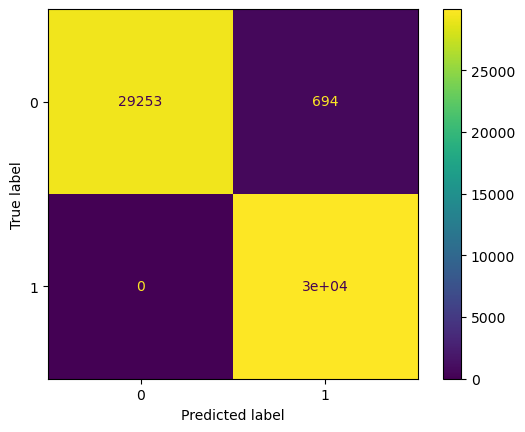

KNN - Accuracy: 0.9884126692601807, Precision: 0.9773498694516971, Recall: 1.0, F1 Score: 0.9885452084640016 


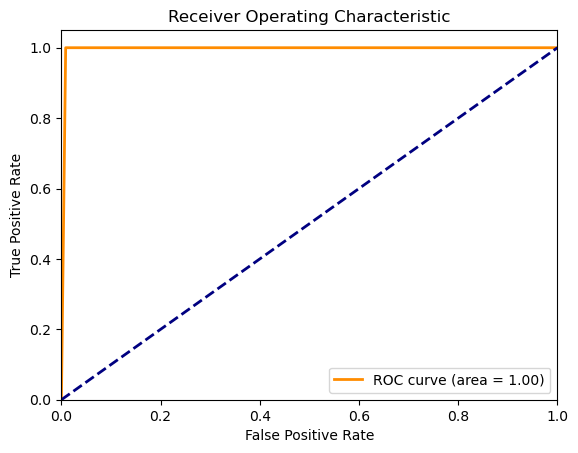

In [27]:
# Train the model  
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set  
metrics_knn = evaluate_model(model_knn, X_val_resampled, y_val_resampled)
print(f'KNN - Accuracy: {metrics_knn[0]}, Precision: {metrics_knn[1]}, Recall: {metrics_knn[2]}, F1 Score: {metrics_knn[3]} ')

# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = model_knn.predict_proba(X_val_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final model on the entire resampled training data
model_knn.fit(X_train_res, y_train_res)

# test data  
y_test_pred_proba = model_knn.predict_proba(X_test_scaled)[:, 1]

# submission file  
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_knn.csv', index=False)


* score for test : private: 0.50742, public: 0.52184

### Balanced Random Forest (BRF) 

C:\Users\Msys\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Msys\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Msys\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


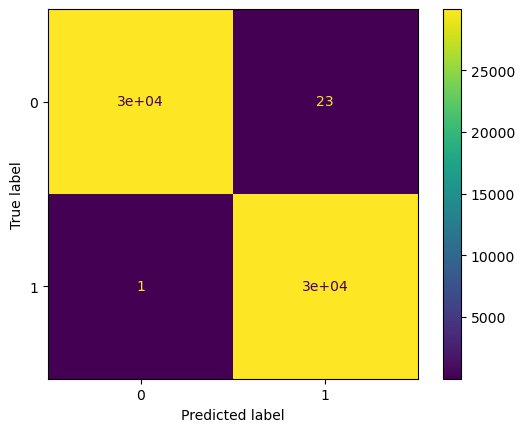

Balanced Random Forest - Accuracy: 0.9995992853922829, Precision: 0.9992325146823278, Recall: 0.9999666065584719, F1 Score: 0.9995994258437093 


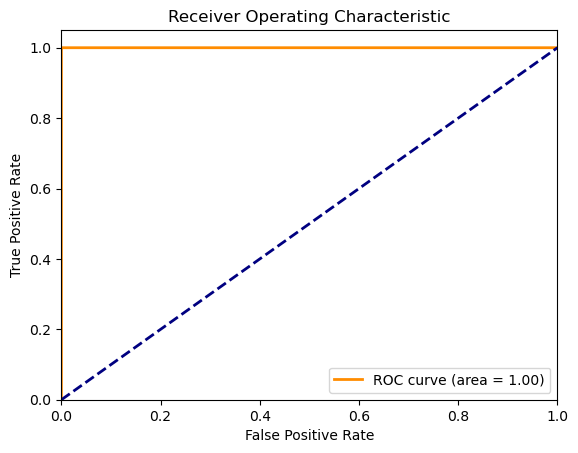

C:\Users\Msys\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Msys\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
C:\Users\Msys\anaconda3\Lib\site-packages\imblearn\ensemble\_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


In [28]:
# Train the model  
model_brf = BalancedRandomForestClassifier(random_state=42)
model_brf.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set  
metrics_brf = evaluate_model(model_brf, X_val_resampled, y_val_resampled)
print(f'Balanced Random Forest - Accuracy: {metrics_brf[0]}, Precision: {metrics_brf[1]}, Recall: {metrics_brf[2]}, F1 Score: {metrics_brf[3]} ')

# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = model_brf.predict_proba(X_val_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final model on the entire resampled training data
model_brf.fit(X_train_res, y_train_res)

# test data 
y_test_pred_proba = model_brf.predict_proba(X_test_scaled)[:, 1]

# submission file 
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_balanced_random.csv', index=False)


* score for test : private:0.61986  , public: 0.67295

### LightGBM

[LightGBM] [Info] Number of positive: 95866, number of negative: 95789
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 191655, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500201 -> initscore=0.000804
[LightGBM] [Info] Start training from score 0.000804
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[65]	valid_0's auc: 0.955075
Accuracy: 0.89
ROC AUC: 0.96
              precision    recall  f1-sc

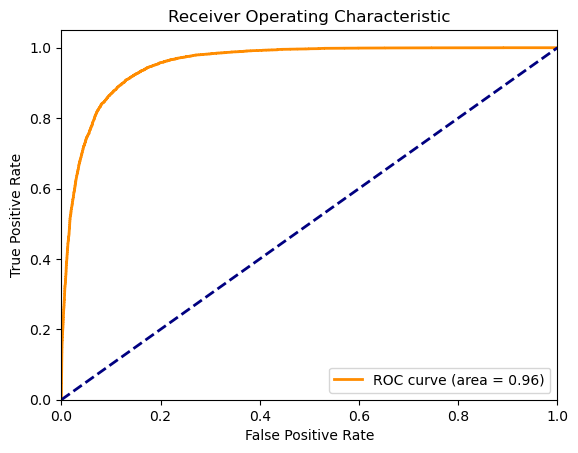

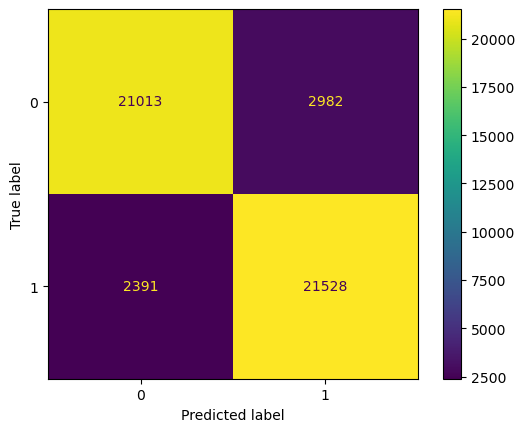

LightGBM - Accuracy: 0.89, Precision: 0.88, Recall: 0.90, F1 Score: 0.89, ROC-AUC: 0.96
[LightGBM] [Info] Number of positive: 269, number of negative: 149731
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010674 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 150000, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001793 -> initscore=-6.321884
[LightGBM] [Info] Start training from score -6.321884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [29]:
# Define evaluate function 
def evaluate_model_2(y_val_pred_prob, y_val):
    y_val_pred = (y_val_pred_prob > 0.5).astype(int)
    
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_pred_prob)
    
    # Display confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    
    return accuracy, precision, recall, f1, roc_auc

# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

# Create LightGBM datasets
dtrain = lgb.Dataset(X_train_split, label=y_train_split)
dval = lgb.Dataset(X_val_split, label=y_val_split, reference=dtrain)

# Set parameters
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.1,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': sum(y_train_split == 0) / sum(y_train_split == 1),  # Handle imbalance
}

# Train model
num_round = 65
bst = lgb.train(params, dtrain, num_boost_round=num_round, valid_sets=[dval], callbacks=[lgb.early_stopping(stopping_rounds=10)])

# validation set
y_pred_prob = bst.predict(X_val_split, num_iteration=bst.best_iteration)

# Evaluate model
accuracy = accuracy_score(y_val_split, (y_pred_prob > 0.5).astype(int))
roc_auc = roc_auc_score(y_val_split, y_pred_prob)
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")
print(classification_report(y_val_split, (y_pred_prob > 0.5).astype(int)))

# Compute ROC curve and ROC area for the validation set
fpr, tpr, _ = roc_curve(y_val_split, y_pred_prob)
roc_auc = auc(fpr, tpr)

 
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Convert DMatrix to array format for validation data
X_val_array = X_val_split   
y_val_array = y_val_split   

# Evaluate on validation set using binary predictions
metrics_lgbm = evaluate_model_2(y_pred_prob, y_val_array)  # Pass predicted probabilities and true labels
print(f'LightGBM - Accuracy: {metrics_lgbm[0]:.2f}, Precision: {metrics_lgbm[1]:.2f}, Recall: {metrics_lgbm[2]:.2f}, F1 Score: {metrics_lgbm[3]:.2f}, ROC-AUC: {metrics_lgbm[4]:.2f}')

# Final model training
dtrain_final = lgb.Dataset(X_train_scaled, label=y_train)
bst_final = lgb.train(params, dtrain_final, num_boost_round=num_round)

# test data
y_test_pred_proba_lgbm = bst_final.predict(X_test_scaled, num_iteration=bst_final.best_iteration)

# submission file
submission_lgbm = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba_lgbm})
submission_lgbm.to_csv('submission_lgbm.csv', index=False)


* score for test : private:0.55117   , public:  0.65742

### XGBoost

[0]	train-auc:0.77905	eval-auc:0.77777
[1]	train-auc:0.82018	eval-auc:0.82021
[2]	train-auc:0.82763	eval-auc:0.82719
[3]	train-auc:0.83756	eval-auc:0.83594
[4]	train-auc:0.84361	eval-auc:0.84316
[5]	train-auc:0.84742	eval-auc:0.84707
[6]	train-auc:0.85593	eval-auc:0.85547
[7]	train-auc:0.86049	eval-auc:0.86013
[8]	train-auc:0.86888	eval-auc:0.86850
[9]	train-auc:0.86936	eval-auc:0.86893
[10]	train-auc:0.87399	eval-auc:0.87349
[11]	train-auc:0.87807	eval-auc:0.87724
[12]	train-auc:0.87889	eval-auc:0.87827
[13]	train-auc:0.88134	eval-auc:0.88062
[14]	train-auc:0.88447	eval-auc:0.88377
[15]	train-auc:0.88654	eval-auc:0.88611
[16]	train-auc:0.88968	eval-auc:0.88914
[17]	train-auc:0.89337	eval-auc:0.89279
[18]	train-auc:0.89505	eval-auc:0.89445
[19]	train-auc:0.89760	eval-auc:0.89680
[20]	train-auc:0.89942	eval-auc:0.89887
[21]	train-auc:0.90133	eval-auc:0.90074
[22]	train-auc:0.90402	eval-auc:0.90340
[23]	train-auc:0.90586	eval-auc:0.90519
[24]	train-auc:0.90791	eval-auc:0.90721
[25]	train

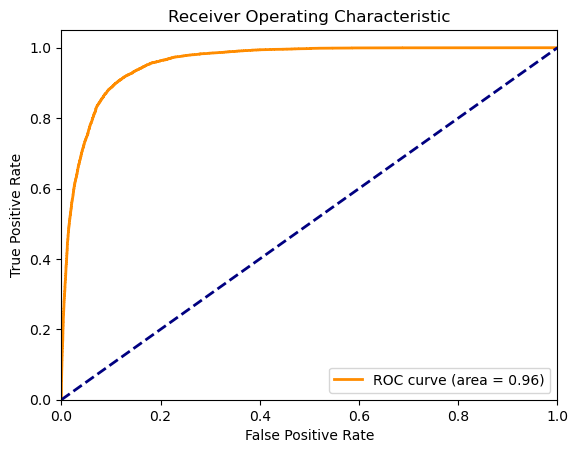

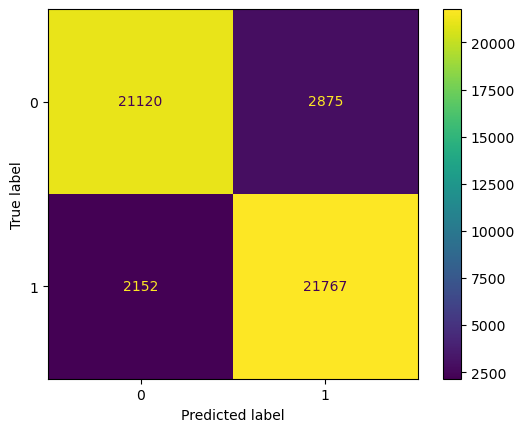

XGBoost - Accuracy: 0.90, Precision: 0.88, Recall: 0.91, F1 Score: 0.90, ROC-AUC: 0.96


In [30]:
# Define evaluate function  
def evaluate_model_3(y_val_pred_prob, y_val):
    y_val_pred = (y_val_pred_prob > 0.5).astype(int)
    
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_pred_prob)
    
    # Display confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    
    return accuracy, precision, recall, f1, roc_auc

# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train_split, label=y_train_split)
dval = xgb.DMatrix(X_val_split, label=y_val_split)
dtest = xgb.DMatrix(X_test_scaled)

# Set parameters
params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'eta': 0.1,
    'max_depth': 4,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': sum(y_train_split == 0) / sum(y_train_split == 1)  # Handle imbalance
}

# Train model
num_round = 65
watchlist = [(dtrain, 'train'), (dval, 'eval')]
bst = xgb.train(params, dtrain, num_boost_round=num_round, evals=watchlist, early_stopping_rounds=10)

# validation set
y_pred_prob = bst.predict(dval)

# Evaluate model
accuracy = accuracy_score(y_val_split, (y_pred_prob > 0.5).astype(int))
roc_auc = roc_auc_score(y_val_split, y_pred_prob)
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")
print(classification_report(y_val_split, (y_pred_prob > 0.5).astype(int)))

# Compute ROC curve and ROC area for the validation set
fpr, tpr, _ = roc_curve(y_val_split, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Convert DMatrix to array format for validation data
X_val_array = X_val_split   
y_val_array = y_val_split   

# Evaluate on validation set using binary predictions
metrics_xgb = evaluate_model_3(y_pred_prob, y_val_array)   
print(f'XGBoost - Accuracy: {metrics_xgb[0]:.2f}, Precision: {metrics_xgb[1]:.2f}, Recall: {metrics_xgb[2]:.2f}, F1 Score: {metrics_xgb[3]:.2f}, ROC-AUC: {metrics_xgb[4]:.2f}')

# Final model training
dtrain_final = xgb.DMatrix(X_train_scaled, label=y_train)
bst_final = xgb.train(params, dtrain_final, num_boost_round=num_round)

# test data
y_test_pred_proba_xgb = bst_final.predict(dtest)

# submission file 
submission_xgb = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba_xgb})
submission_xgb.to_csv('submission_xgb.csv', index=False)


* score for test : private:0.69479   , public:  0.79683

# Method to improve the chosen algorithm 

### NaiveBayes

1. using other types of Naive Bayes

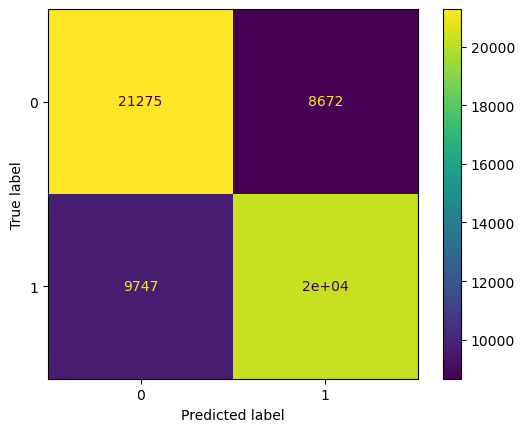

Bernoulli Naive Bayes - Accuracy: 0.6924682350191175, Precision: 0.6996293858889543, Recall: 0.6745141254257664, F1 Score: 0.6868422394885831 


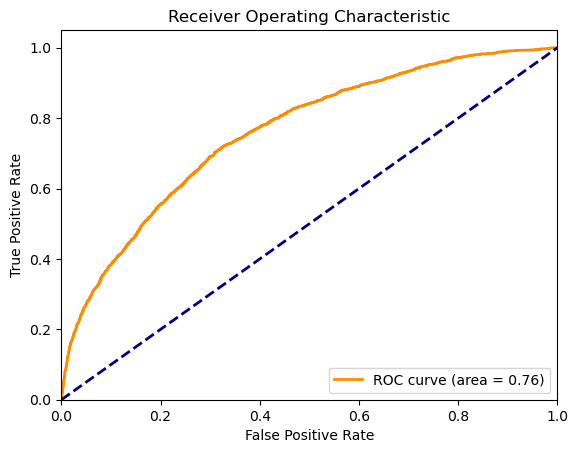

In [31]:
 # Train the model using Bernoulli Naive Bayes
model_nb = BernoulliNB()
model_nb.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set  
metrics_nb = evaluate_model(model_nb, X_val_resampled, y_val_resampled)
print(f'Bernoulli Naive Bayes - Accuracy: {metrics_nb[0]}, Precision: {metrics_nb[1]}, Recall: {metrics_nb[2]}, F1 Score: {metrics_nb[3]} ')

# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = model_nb.predict_proba(X_val_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final model on the entire resampled training data
model_nb.fit(X_train_res, y_train_res)

# test data 
y_test_pred_proba = model_nb.predict_proba(X_test_scaled)[:, 1]

# submission file
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_BernoulliNB.csv', index=False)


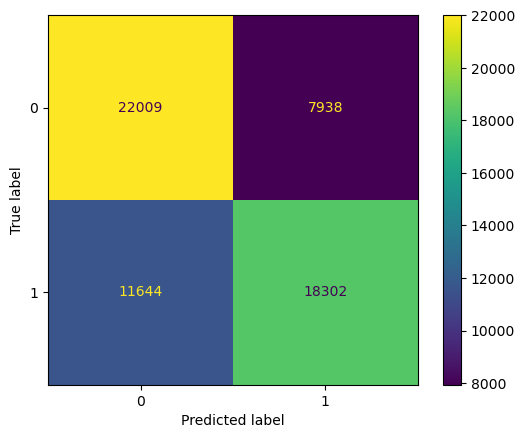

Complement Naive Bayes - Accuracy: 0.6730502729868265, Precision: 0.697484756097561, Recall: 0.6111667668469912, F1 Score: 0.6514790161250132


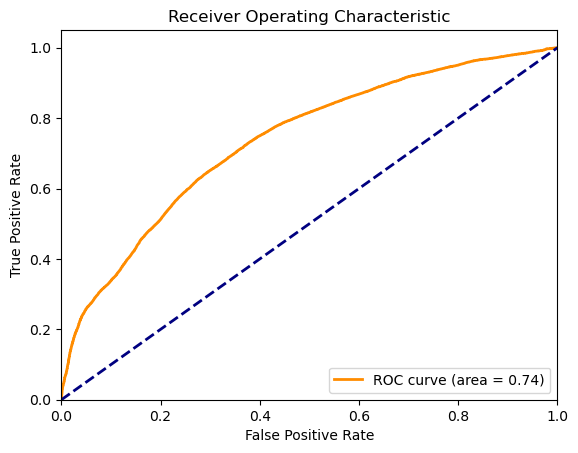

In [32]:
#using Complement Naive Bayes
# Apply Min-Max scaling to ensure non-negative feature values
scaler = MinMaxScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_val_resampled_scaled = scaler.transform(X_val_resampled)
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test_scaled)

# Train the model  
model_nb = ComplementNB()
model_nb.fit(X_train_resampled_scaled, y_train_resampled)

# Evaluate on validation set 
metrics_nb = evaluate_model(model_nb, X_val_resampled_scaled, y_val_resampled)
print(f'Complement Naive Bayes - Accuracy: {metrics_nb[0]}, Precision: {metrics_nb[1]}, Recall: {metrics_nb[2]}, F1 Score: {metrics_nb[3]}')

# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = model_nb.predict_proba(X_val_resampled_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final model on the entire resampled training data
model_nb.fit(X_train_res_scaled, y_train_res)

# test data 
y_test_pred_proba = model_nb.predict_proba(X_test_scaled)[:, 1]

# submission file 
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_ComplementNB.csv', index=False)


2. Ensemble Methods

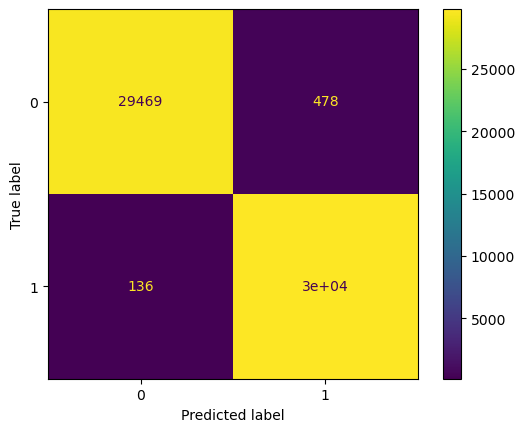

Stacking - Accuracy: 0.9897483846192376, Precision: 0.9842181722134179, Recall: 0.9954584919521806, F1 Score: 0.9898064216223396


In [33]:
# Create stacking classifier
# base models
base_models = [
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=42))
]
# meta model
meta_model = LogisticRegression(random_state=42)

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

# Train the stacking classifier
stacking_clf.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set  
metrics_stacking = evaluate_model(stacking_clf, X_val_resampled, y_val_resampled)
print(f'Stacking - Accuracy: {metrics_stacking[0]}, Precision: {metrics_stacking[1]}, Recall: {metrics_stacking[2]}, F1 Score: {metrics_stacking[3]}')

# Train the final model on the entire resampled training data
stacking_clf.fit(X_train_res, y_train_res)

# test data  
y_test_pred_proba = stacking_clf.predict_proba(X_test_scaled)[:, 1]

# submission file  
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_stacking_naive.csv', index=False)


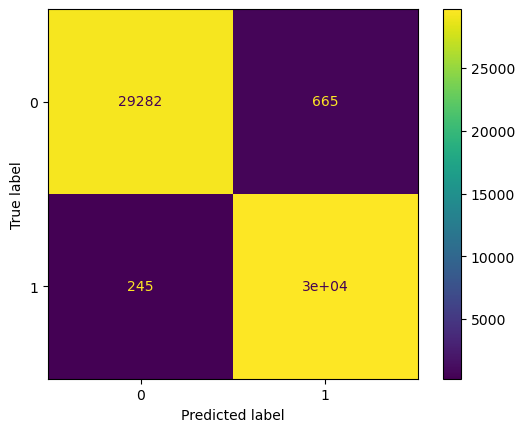

Voting Classifier - Accuracy: 0.9848062377907268, Precision: 0.9781005071461503, Recall: 0.9918186068256194, F1 Score: 0.984911792014856 


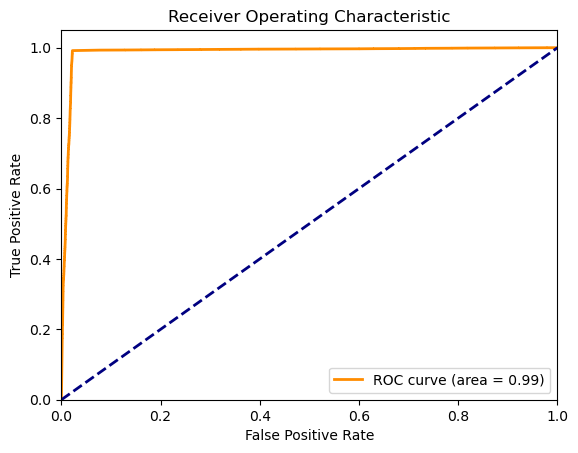

In [34]:
# Voting Classifier
# Define the individual models
model_nb = GaussianNB()
model_rf = RandomForestClassifier(n_estimators=1, random_state=42)

# Combine the models into a Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('nb', model_nb),
    ('rf', model_rf)
], voting='soft')

# Train the model
voting_clf.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set  
metrics_voting = evaluate_model(voting_clf, X_val_resampled, y_val_resampled)
print(f'Voting Classifier - Accuracy: {metrics_voting[0]}, Precision: {metrics_voting[1]}, Recall: {metrics_voting[2]}, F1 Score: {metrics_voting[3]} ')

# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = voting_clf.predict_proba(X_val_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final Voting Classifier on the entire resampled training data
voting_clf.fit(X_train_res, y_train_res)

# test data 
y_test_pred_proba = voting_clf.predict_proba(X_test_scaled)[:, 1]

# submission file  
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_VotingClassifier_naive.csv', index=False)


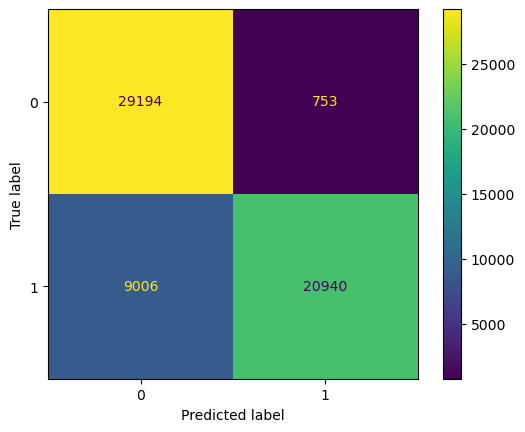

Voting Classifier - Accuracy: 0.837059422637036, Precision: 0.96528834186143, Recall: 0.6992586655980766, F1 Score: 0.8110149305757277 


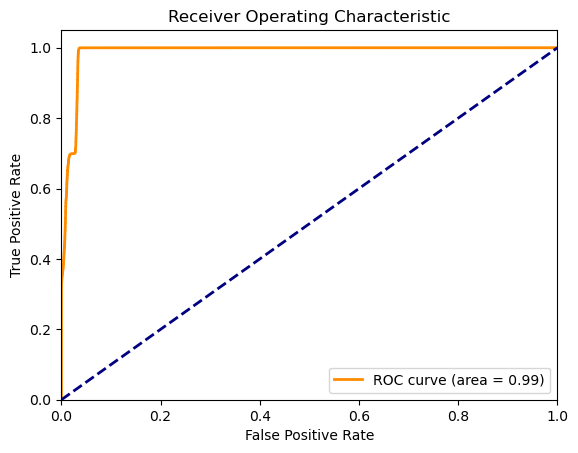

In [35]:
#Voting Classifier
# Define the individual models
model_nb = GaussianNB()
model_xgb = XGBClassifier(n_estimators=5000, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Combine the models into a Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('nb', model_nb),
    ('xgb', model_xgb)
], voting='soft')

# Train the model
voting_clf.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set  
metrics_voting = evaluate_model(voting_clf, X_val_resampled, y_val_resampled)
print(f'Voting Classifier - Accuracy: {metrics_voting[0]}, Precision: {metrics_voting[1]}, Recall: {metrics_voting[2]}, F1 Score: {metrics_voting[3]} ')

# Compute ROC curve and ROC area for the validation set
y_val_pred_proba = voting_clf.predict_proba(X_val_resampled)[:, 1]
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final Voting Classifier on the entire resampled training data
voting_clf.fit(X_train_res, y_train_res)

# test data 
y_test_pred_proba = voting_clf.predict_proba(X_test_scaled)[:, 1]

# submission file  
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_VotingClassifier_naive2.csv', index=False)


3. Feature Selection + Dimensionality reduction- PCA + Hyperparameter tuning for Naive Bayes (smoothing parameter)

Best parameters found:  {'nb__var_smoothing': 1e-05}
Improved Naive Bayes - Accuracy: 0.6476048953967909, Precision: 0.8613472858077175, Recall: 0.3518332999398918, F1 Score: 0.49959694627530943 


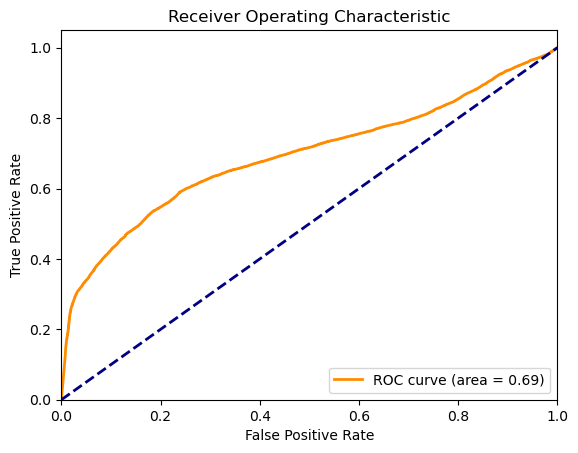

In [36]:
# Feature selection
select_k_best = SelectKBest(mutual_info_classif, k=20)

# Dimensionality reduction
pca = PCA(n_components=10)

# Naive Bayes model 
nb = GaussianNB()

# Pipeline for processing
pipeline = Pipeline([
    ('select_k_best', select_k_best),
    ('pca', pca),
    ('nb', nb)
])

# Hyperparameter tuning (smoothing parameter)
param_grid = {'nb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}

# Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train_resampled, y_train_resampled)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Evaluate on validation set
y_val_pred_proba = grid_search.predict_proba(X_val_resampled)[:, 1]
metrics_nb = {
    'accuracy': accuracy_score(y_val_resampled, grid_search.predict(X_val_resampled)),
    'precision': precision_score(y_val_resampled, grid_search.predict(X_val_resampled)),
    'recall': recall_score(y_val_resampled, grid_search.predict(X_val_resampled)),
    'f1_score': f1_score(y_val_resampled, grid_search.predict(X_val_resampled)),
    'roc_auc': roc_auc_score(y_val_resampled, y_val_pred_proba)
}

print(f'Improved Naive Bayes - Accuracy: {metrics_nb["accuracy"]}, Precision: {metrics_nb["precision"]}, Recall: {metrics_nb["recall"]}, F1 Score: {metrics_nb["f1_score"]} ')

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val_resampled, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Train the final model on the entire resampled training data
pipeline.fit(X_train_res, y_train_res)

# test data  
y_test_pred_proba = pipeline.predict_proba(X_test_scaled)[:, 1]

# submission file 
submission = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba})
submission.to_csv('submission_final_project_naive3.csv', index=False)


### XGBoost

1. Hyperparameter Tuning +  Feature selection 

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best Threshold=0.697112, F-Score=0.997


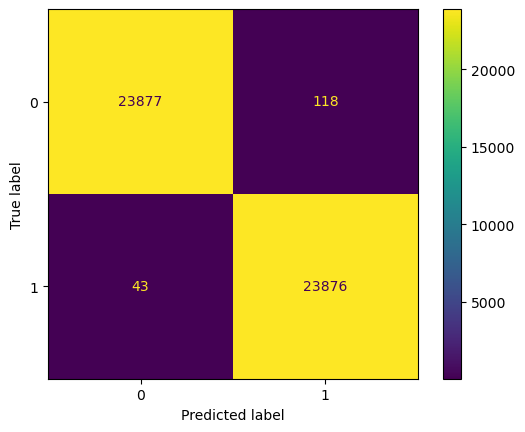

XGBoost - Accuracy: 1.00, Precision: 1.00, Recall: 1.00, F1 Score: 1.00, ROC-AUC: 1.00


In [37]:
# Define evaluate function  
def evaluate_model_4(y_val_pred_prob, y_val, threshold=0.5):
    y_val_pred = (y_val_pred_prob > threshold).astype(int)
    
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_pred_prob)
    
    # Display confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    
    return accuracy, precision, recall, f1, roc_auc

# Feature selection
selector = SelectKBest(f_classif, k=20)  # Select top 20 features
X_new = selector.fit_transform(X_train_resampled, y_train_resampled)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_new, y_train_resampled, test_size=0.2, random_state=42)

# Set initial parameters
xgb_model = xgb.XGBClassifier(objective='binary:logistic', scale_pos_weight=sum(y_train_split == 0) / sum(y_train_split == 1))

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist, scoring='roc_auc', cv=3, n_iter=50, verbose=1, random_state=42)
random_search.fit(X_train_split, y_train_split)

best_params = random_search.best_params_
print("Best parameters:", best_params)

# Train model with best parameters
xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X_train_split, y_train_split)

# Make predictions on validation set
y_pred_prob = xgb_model.predict_proba(X_val_split)[:, 1]

# Threshold tuning
precision, recall, thresholds = precision_recall_curve(y_val_split, y_pred_prob)
fscore = (2 * precision * recall) / (precision + recall)
ix = np.argmax(fscore)
best_threshold = thresholds[ix]
print('Best Threshold=%f, F-Score=%.3f' % (best_threshold, fscore[ix]))

# Evaluate model with the best threshold
metrics_xgb = evaluate_model_4(y_pred_prob, y_val_split, threshold=best_threshold)
print(f'XGBoost - Accuracy: {metrics_xgb[0]:.2f}, Precision: {metrics_xgb[1]:.2f}, Recall: {metrics_xgb[2]:.2f}, F1 Score: {metrics_xgb[3]:.2f}, ROC-AUC: {metrics_xgb[4]:.2f}')

# Final model training with the entire training data
X_train_final = selector.transform(X_train_scaled)  # Apply the same feature selection
xgb_model.fit(X_train_final, y_train)

# test data
X_test_final = selector.transform(X_test_scaled)  # Apply the same feature selection
y_test_pred_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

# submission file
submission_xgb = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba_xgb})
submission_xgb.to_csv('submission_xgb_h1.csv', index=False)


2. Hyperparameter Tuning +  Feature selection + Regularization

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters: {'subsample': 0.6, 'reg_lambda': 0.01, 'reg_alpha': 1, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
[0]	validation_0-logloss:0.66308
[1]	validation_0-logloss:0.63668


C:\Users\Msys\anaconda3\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[2]	validation_0-logloss:0.61509
[3]	validation_0-logloss:0.59500
[4]	validation_0-logloss:0.57771
[5]	validation_0-logloss:0.56313
[6]	validation_0-logloss:0.54885
[7]	validation_0-logloss:0.53512
[8]	validation_0-logloss:0.52251
[9]	validation_0-logloss:0.51359
[10]	validation_0-logloss:0.50513
[11]	validation_0-logloss:0.49783
[12]	validation_0-logloss:0.48794
[13]	validation_0-logloss:0.48116
[14]	validation_0-logloss:0.47277
[15]	validation_0-logloss:0.46695
[16]	validation_0-logloss:0.46158
[17]	validation_0-logloss:0.45387
[18]	validation_0-logloss:0.44787
[19]	validation_0-logloss:0.44030
[20]	validation_0-logloss:0.43548
[21]	validation_0-logloss:0.43012
[22]	validation_0-logloss:0.42467
[23]	validation_0-logloss:0.41892
[24]	validation_0-logloss:0.41427
[25]	validation_0-logloss:0.40822
[26]	validation_0-logloss:0.40431
[27]	validation_0-logloss:0.39889
[28]	validation_0-logloss:0.39466
[29]	validation_0-logloss:0.39040
[30]	validation_0-logloss:0.38507
[31]	validation_0-logl

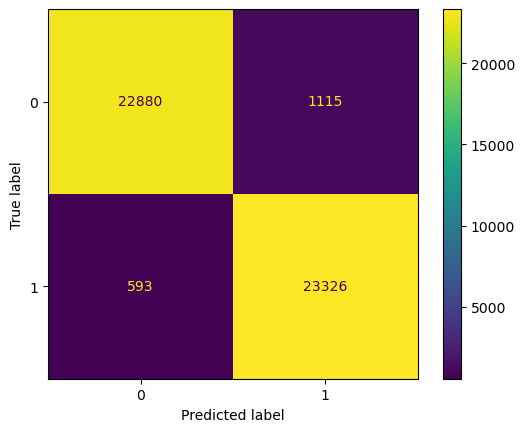

XGBoost - Accuracy: 0.96, Precision: 0.95, Recall: 0.98, F1 Score: 0.96, ROC-AUC: 0.99
[0]	validation_0-logloss:0.11871
[1]	validation_0-logloss:0.10744
[2]	validation_0-logloss:0.09738
[3]	validation_0-logloss:0.08838
[4]	validation_0-logloss:0.08032
[5]	validation_0-logloss:0.07313
[6]	validation_0-logloss:0.06665
[7]	validation_0-logloss:0.06085
[8]	validation_0-logloss:0.05564


C:\Users\Msys\anaconda3\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[9]	validation_0-logloss:0.05095
[10]	validation_0-logloss:0.04673
[11]	validation_0-logloss:0.04296
[12]	validation_0-logloss:0.03957
[13]	validation_0-logloss:0.03651
[14]	validation_0-logloss:0.03375
[15]	validation_0-logloss:0.03126
[16]	validation_0-logloss:0.02904
[17]	validation_0-logloss:0.02703
[18]	validation_0-logloss:0.02522
[19]	validation_0-logloss:0.02361
[20]	validation_0-logloss:0.02215
[21]	validation_0-logloss:0.02083
[22]	validation_0-logloss:0.01966
[23]	validation_0-logloss:0.01860
[24]	validation_0-logloss:0.01765
[25]	validation_0-logloss:0.01680
[26]	validation_0-logloss:0.01599
[27]	validation_0-logloss:0.01529
[28]	validation_0-logloss:0.01467
[29]	validation_0-logloss:0.01409
[30]	validation_0-logloss:0.01359
[31]	validation_0-logloss:0.01314
[32]	validation_0-logloss:0.01273
[33]	validation_0-logloss:0.01234
[34]	validation_0-logloss:0.01201
[35]	validation_0-logloss:0.01169
[36]	validation_0-logloss:0.01140
[37]	validation_0-logloss:0.01113
[38]	validation

In [38]:
# Define evaluate function  
def evaluate_model_5(y_val_pred_prob, y_val, threshold=0.5):
    y_val_pred = (y_val_pred_prob > threshold).astype(int)
    
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_pred_prob)
    
    # Display confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    
    return accuracy, precision, recall, f1, roc_auc

# Feature selection
selector = SelectKBest(f_classif, k=20)  # Select top 20 features
X_new = selector.fit_transform(X_train_resampled, y_train_resampled)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_new, y_train_resampled, test_size=0.2, random_state=42)

# Set initial parameters
xgb_model = xgb.XGBClassifier(objective='binary:logistic', scale_pos_weight=sum(y_train_split == 0) / sum(y_train_split == 1))

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0.01, 0.1, 1],  # L1 regularization
    'reg_lambda': [0.01, 0.1, 1]  # L2 regularization
}

random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist, scoring='roc_auc', cv=3, n_iter=50, verbose=1, random_state=42)
random_search.fit(X_train_split, y_train_split)

best_params = random_search.best_params_
print("Best parameters:", best_params)

# Train model with best parameters
xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X_train_split, y_train_split, eval_set=[(X_val_split, y_val_split)], early_stopping_rounds=10, verbose=True)

# Make predictions on validation set
y_pred_prob = xgb_model.predict_proba(X_val_split)[:, 1]

# Threshold tuning
precision, recall, thresholds = precision_recall_curve(y_val_split, y_pred_prob)
fscore = (2 * precision * recall) / (precision + recall)
ix = np.argmax(fscore)
best_threshold = thresholds[ix]
print('Best Threshold=%f, F-Score=%.3f' % (best_threshold, fscore[ix]))

# Evaluate model with the best threshold
metrics_xgb = evaluate_model_5(y_pred_prob, y_val_split, threshold=best_threshold)
print(f'XGBoost - Accuracy: {metrics_xgb[0]:.2f}, Precision: {metrics_xgb[1]:.2f}, Recall: {metrics_xgb[2]:.2f}, F1 Score: {metrics_xgb[3]:.2f}, ROC-AUC: {metrics_xgb[4]:.2f}')

# Final model training with the entire training data
X_train_final = selector.transform(X_train_scaled)  # Apply the same feature selection
xgb_model.fit(X_train_final, y_train, eval_set=[(X_train_final, y_train)], early_stopping_rounds=10, verbose=True)

# test data
X_test_final = selector.transform(X_test_scaled)  # Apply the same feature selection
y_test_pred_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

# submission file
submission_xgb = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba_xgb})
submission_xgb.to_csv('submission_xgb_h2.csv', index=False)


3. Ensemble Methods: RandomizedSearchCV for XGBoost hyperparameter tuning + RandomizedSearchCV for LightGBM hyperparameter tuning

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Warning] lambda_l1 is set=0.7704285838459497, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7704285838459497
[LightGBM] [Warning] lambda_l2 is set=7.391963650868431, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.391963650868431
[LightGBM] [Warning] lambda_l1 is set=0.7704285838459497, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7704285838459497
[LightGBM] [Warning] lambda_l2 is set=7.391963650868431, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.391963650868431
[LightGBM] [Info] Number of positive: 63910, number of negative: 63860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000519 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Inf

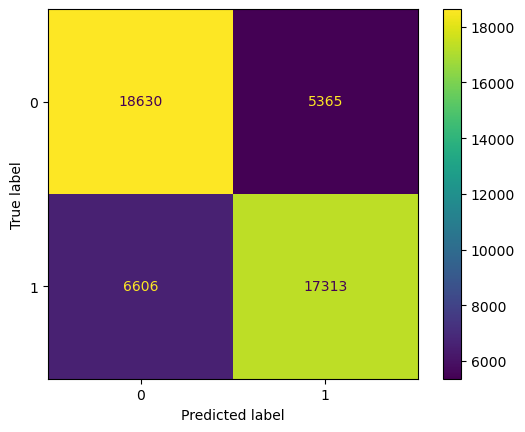

Stacking Ensemble - Accuracy: 0.75, Precision: 0.76, Recall: 0.72, F1 Score: 0.74, ROC-AUC: 0.85
[LightGBM] [Warning] lambda_l1 is set=0.6813181884524238, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.6813181884524238
[LightGBM] [Warning] lambda_l2 is set=3.447303862078625, reg_lambda=0.0 will be ignored. Current value: lambda_l2=3.447303862078625


In [39]:
#stacking ensemble
# Define function to evaluate model
def evaluate_model_6(y_val_pred_prob, y_val):
    y_val_pred = (y_val_pred_prob > 0.5).astype(int)
    
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc_auc = roc_auc_score(y_val, y_val_pred_prob)
    
    # Display confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    
    return accuracy, precision, recall, f1, roc_auc

# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

# Feature selection using XGBoost's feature importances
xgb_clf_fs = xgb.XGBClassifier(use_label_encoder=False, n_jobs=-1)
xgb_clf_fs.fit(X_train_split, y_train_split)

# Select features based on feature importances
selection = SelectFromModel(xgb_clf_fs, threshold='mean', prefit=True)
X_train_split_selected = selection.transform(X_train_split)
X_val_split_selected = selection.transform(X_val_split)
X_train_resampled_selected = selection.transform(X_train_resampled)  # Apply to full training data
X_test_scaled_selected = selection.transform(X_test_scaled)  # Apply to test data

# Use RandomizedSearchCV for XGBoost hyperparameter tuning
param_distributions_xgb = {
    'eta': uniform(0.005, 0.015),
    'max_depth': randint(2, 4),
    'subsample': uniform(0.4, 0.2),
    'colsample_bytree': uniform(0.4, 0.2),
    'gamma': uniform(0, 0.4),
    'lambda': uniform(3, 6),
    'alpha': uniform(0.2, 0.6)
}

xgb_clf = xgb.XGBClassifier(use_label_encoder=False, n_jobs=-1)
random_search_xgb = RandomizedSearchCV(estimator=xgb_clf, param_distributions=param_distributions_xgb, n_iter=50, scoring='roc_auc', cv=3, verbose=1, random_state=42)
random_search_xgb.fit(X_train_split_selected, y_train_split)
best_params_xgb = random_search_xgb.best_params_
xgb_clf_best = xgb.XGBClassifier(**best_params_xgb, use_label_encoder=False, n_jobs=-1)
xgb_clf_best.fit(X_train_resampled_selected, y_train_resampled)

# Use RandomizedSearchCV for LightGBM hyperparameter tuning
param_distributions_lgb = {
    'learning_rate': uniform(0.005, 0.015),
    'max_depth': randint(2, 4),
    'subsample': uniform(0.4, 0.2),
    'colsample_bytree': uniform(0.4, 0.2),
    'lambda_l1': uniform(0.2, 0.6),
    'lambda_l2': uniform(3, 6)
}

lgb_clf = lgb.LGBMClassifier(n_jobs=-1)
random_search_lgb = RandomizedSearchCV(estimator=lgb_clf, param_distributions=param_distributions_lgb, n_iter=50, scoring='roc_auc', cv=3, verbose=1, random_state=42)
random_search_lgb.fit(X_train_split_selected, y_train_split)
best_params_lgb = random_search_lgb.best_params_
lgb_clf_best = lgb.LGBMClassifier(**best_params_lgb, n_jobs=-1)
lgb_clf_best.fit(X_train_resampled_selected, y_train_resampled)

# Define the stacking ensemble
estimators = [
    ('xgb', xgb_clf_best),
    ('lgb', lgb_clf_best)
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

# Train the stacking ensemble
stacking_clf.fit(X_train_resampled_selected, y_train_resampled)

# Make predictions on the validation set using the stacking ensemble
y_pred_prob_stack = stacking_clf.predict_proba(X_val_split_selected)[:, 1]

# Evaluate the stacking ensemble
metrics_stack = evaluate_model_6(y_pred_prob_stack, y_val_split)
print(f'Stacking Ensemble - Accuracy: {metrics_stack[0]:.2f}, Precision: {metrics_stack[1]:.2f}, Recall: {metrics_stack[2]:.2f}, F1 Score: {metrics_stack[3]:.2f}, ROC-AUC: {metrics_stack[4]:.2f}')

# test set  
y_test_pred_proba_stack = stacking_clf.predict_proba(X_test_scaled_selected)[:, 1]

# submission file
submission_stack = pd.DataFrame({'id': df_test['id'], 'isFraud': y_test_pred_proba_stack})
submission_stack.to_csv('submission_stack_xgboost.csv', index=False)
